In [ ]:
# ---------- Environment setup (Colab installs PySpark + kagglehub; local runs skip this) ----------
import os, sys, subprocess
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    subprocess.run("pip -q install pyspark==3.5.3 kagglehub", shell=True, check=False)
    if subprocess.run("java -version", shell=True, capture_output=True).returncode != 0:
        subprocess.run("apt-get -qq update && apt-get -qq install -y openjdk-17-jdk-headless", shell=True)

In [ ]:
# ---------- Configuration ----------
import glob, json, time, math, shutil, urllib.request, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

BASE  = os.environ.get("CC_BASE", "/content/chicago_crime" if IN_COLAB else os.path.abspath("chicago_crime"))
RAW   = f"{BASE}/raw"          # landing zone (immutable raw files)
LAKE  = f"{BASE}/lake"         # curated Parquet lake
FIG   = f"{BASE}/figures"
TAB   = f"{BASE}/tables"
for d in (RAW, f"{RAW}/crime", f"{RAW}/weather", f"{RAW}/socio", LAKE, FIG, TAB):
    os.makedirs(d, exist_ok=True)

SILVER_PATH     = f"{LAKE}/crimes_silver"      # partitioned by year / district
QUARANTINE_PATH = f"{LAKE}/crimes_quarantine"
WEATHER_PATH    = f"{LAKE}/weather_daily"
SOCIO_PATH      = f"{LAKE}/socio_economic"

# Chicago bounding box used to validate coordinates (city limits + small margin)
BBOX = dict(lat_min=41.64, lat_max=42.03, lon_min=-87.95, lon_max=-87.52)
CHICAGO_LAT, CHICAGO_LON = 41.88, -87.63   # point used for the weather series

# Analysis knobs — lower these if Colab runs out of memory/time
CLUSTER_YEAR          = None     # None = latest complete year in the data
CLUSTER_SAMPLE_FRAC   = float(os.environ.get("CC_CLUSTER_FRAC", 1.0))
K_RANGE               = list(range(2, 16))
TIME_WEIGHT           = 1.0      # weight of the time-of-day dimensions relative to space
PURITY_THRESHOLD      = 0.60     # cluster is "cross-boundary" if < 60% of it sits in one district
MODEL_YEARS           = 5        # most recent N years used for supervised learning
MODEL_SAMPLE_FRAC     = float(os.environ.get("CC_MODEL_FRAC", 0.30))
RF_TREES              = int(os.environ.get("CC_RF_TREES", 60))
GBT_ITERS             = int(os.environ.get("CC_GBT_ITERS", 40))
TOP_LOCATIONS         = 40       # keep top-N location descriptions, rest -> OTHER
TOP_TYPES             = 10       # multiclass model: top-N primary types, rest -> OTHER
SEED                  = 42
DRIVER_MEMORY         = os.environ.get("CC_DRIVER_MEM", "8g")

plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.3})
def savefig(name):
    plt.tight_layout(); plt.savefig(f"{FIG}/{name}.png", bbox_inches="tight"); plt.show()
def savetab(pdf, name):
    pdf.to_csv(f"{TAB}/{name}.csv", index=False); return pdf
print("Working directory:", BASE)

Working directory: /content/chicago_crime


In [ ]:
from pyspark.sql import SparkSession, functions as F, types as T, Window
spark = (SparkSession.builder
         .appName("ChicagoCrime-BigData")
         .master("local[*]")
         .config("spark.driver.memory", DRIVER_MEMORY)
         .config("spark.sql.shuffle.partitions", "64")
         .config("spark.sql.adaptive.enabled", "true")
         # Chicago timestamps are local wall-clock; UTC session time avoids DST shifting the hour of day
         .config("spark.sql.session.timeZone", "UTC")
         .config("spark.sql.legacy.timeParserPolicy", "CORRECTED")
         .config("spark.sql.parquet.compression.codec", "snappy")
         .config("spark.ui.showConsoleProgress", "false")
         .getOrCreate())
sc = spark.sparkContext
sc.setLogLevel("ERROR")
print("Spark", spark.version, "| cores:", sc.defaultParallelism)

Spark 3.5.3 | cores: 2


In [ ]:
# Task 1 — Distributed Data Engineering & Pipeline Construction

In [ ]:
# ---------- 1.1 Acquire the raw crime file ----------
CRIME_CSV = os.environ.get("CC_CRIME_CSV")
if not CRIME_CSV:
    cands = glob.glob(f"{RAW}/crime/*.csv")
    if not cands:
        import kagglehub
        dl = kagglehub.dataset_download("utkarshx27/crimes-2001-to-present")
        cands = glob.glob(f"{dl}/**/*.csv", recursive=True)
    CRIME_CSV = max(cands, key=os.path.getsize)
print(CRIME_CSV, f"{os.path.getsize(CRIME_CSV)/1e9:.2f} GB")

100%|██████████| 439M/439M [00:07<00:00, 65.1MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/utkarshx27/crimes-2001-to-present/versions/1/Crimes_-_2001_to_Present.csv 1.84 GB


In [ ]:
# ---------- 1.2 Data contract (schema enforcement policy) ----------
# (column, target Spark SQL type, required)
CONTRACT = [
    ("id",                   "bigint",   True),
    ("case_number",          "string",   False),
    ("date",                 "timestamp",True),
    ("block",                "string",   False),
    ("iucr",                 "string",   False),
    ("primary_type",         "string",   True),
    ("description",          "string",   False),
    ("location_description", "string",   False),
    ("arrest",               "boolean",  True),
    ("domestic",             "boolean",  False),
    ("beat",                 "int",      False),
    ("district",             "int",      False),
    ("ward",                 "int",      False),
    ("community_area",       "int",      False),
    ("fbi_code",             "string",   False),
    ("x_coordinate",         "double",   False),
    ("y_coordinate",         "double",   False),
    ("year",                 "int",      False),
    ("updated_on",           "timestamp",False),
    ("latitude",             "double",   False),
    ("longitude",            "double",   False),
]
TS_FORMATS = ["MM/dd/yyyy hh:mm:ss a", "MM/dd/yyyy HH:mm:ss", "yyyy-MM-dd'T'HH:mm:ss.SSS",
              "yyyy-MM-dd'T'HH:mm:ss", "yyyy-MM-dd HH:mm:ss", "MM/dd/yyyy HH:mm"]

import re
def snake(c):
    return re.sub(r"_+", "_", re.sub(r"[^0-9a-zA-Z]+", "_", c.strip().lower())).strip("_")

bronze_raw = (spark.read
              .option("header", True)
              .option("escape", '"')
              .option("mode", "PERMISSIVE")      # never abort the job on a malformed line
              .csv(CRIME_CSV))                   # every column arrives as string
bronze = bronze_raw.toDF(*[snake(c) for c in bronze_raw.columns])

expected = [c for c, _, _ in CONTRACT]
missing_cols = [c for c in expected if c not in bronze.columns]
extra_cols   = [c for c in bronze.columns if c not in expected]
print("Columns missing from source (added as null):", missing_cols)
print("Unexpected columns (dropped):", extra_cols)
for c in missing_cols:
    bronze = bronze.withColumn(c, F.lit(None).cast("string"))
bronze = bronze.select(expected)

# trim + blank-to-null on every raw string before casting
bronze = bronze.select([F.when(F.trim(F.col(c)) == "", None).otherwise(F.trim(F.col(c))).alias(c)
                        for c in expected])

Columns missing from source (added as null): []
Unexpected columns (dropped): ['location']


In [ ]:
# ---------- 1.3 Typed casting with per-column failure accounting ----------
def parse_ts(col):
    return F.coalesce(*[F.try_to_timestamp(F.col(col), F.lit(fmt)) for fmt in TS_FORMATS])

def parse_bool(col):
    u = F.upper(F.col(col))
    return (F.when(u.isin("TRUE", "T", "Y", "YES", "1"), F.lit(True))
             .when(u.isin("FALSE", "F", "N", "NO", "0"), F.lit(False)))

typed_cols, fail_cols = [], []
for c, t, _ in CONTRACT:
    if t == "timestamp":
        typed = parse_ts(c)
    elif t == "boolean":
        typed = parse_bool(c)
    elif t == "string":
        typed = F.col(c)
    else:
        typed = F.expr(f"try_cast(`{c}` as {t})")
    typed_cols.append(typed.alias(c))
    # cast failure = raw value present but typed value null
    fail_cols.append((F.col(c).isNotNull() & typed.isNull()).alias(f"__fail_{c}"))

# Materialise the typed "bronze" layer once as Parquet: every later pass reads this columnar copy
# instead of re-parsing 1.8 GB of CSV text (Spark is lazy; without this each count() would re-read the CSV).
BRONZE_PATH = f"{LAKE}/crimes_bronze_typed"
t0 = time.time()
bronze.select(*typed_cols, *fail_cols).write.mode("overwrite").parquet(BRONZE_PATH)
typed_df = spark.read.parquet(BRONZE_PATH)
print(f"Typed bronze layer written in {time.time()-t0:.1f}s")

# One aggregation pass computes every cast-failure count (no per-column scans)
fail_counts = typed_df.agg(*[F.sum(F.col(f"__fail_{c}").cast("int")).alias(c) for c, _, _ in CONTRACT]).first().asDict()
cast_report = savetab(pd.DataFrame([(c, t, r, fail_counts[c]) for c, t, r in CONTRACT],
                                   columns=["column", "target_type", "required", "cast_failures"]), "t1_cast_failures")
typed_df = typed_df.drop(*[f"__fail_{c}" for c, _, _ in CONTRACT])
raw_rows = typed_df.count()
print(f"Raw rows: {raw_rows:,}")
cast_report

Typed bronze layer written in 161.2s
Raw rows: 7,784,664


,column,target_type,required,cast_failures
0,id,bigint,True,0
1,case_number,string,False,0
2,date,timestamp,True,0
3,block,string,False,0
4,iucr,string,False,0
5,primary_type,string,True,0
6,description,string,False,0
7,location_description,string,False,0
8,arrest,boolean,True,0
9,domestic,boolean,False,0


In [ ]:
# ---------- 1.4 Quality rules ----------
dq = {}   # rule -> affected rows, for the data-quality report

# (a) Duplicates: the portal re-publishes records when they are updated -> keep the latest version of each ID
w_dup = Window.partitionBy("id").orderBy(F.col("updated_on").desc_nulls_last())
typed_df = typed_df.withColumn("__rn", F.when(F.col("id").isNotNull(), F.row_number().over(w_dup)))
dq["duplicate_id_versions_removed"] = typed_df.filter(F.col("__rn") > 1).count()
typed_df = typed_df.filter((F.col("__rn") == 1) | F.col("__rn").isNull()).drop("__rn")

# (b) Required-field / range rules -> quarantine with a reason
max_ts = F.current_timestamp()
reject = F.concat_ws(";",
    F.when(F.col("id").isNull(), F.lit("invalid_id")),
    F.when(F.col("date").isNull(), F.lit("unparseable_date")),
    F.when((F.col("date") < F.lit("2001-01-01").cast("timestamp")) | (F.col("date") > max_ts), F.lit("date_out_of_range")),
    F.when(F.col("primary_type").isNull(), F.lit("missing_primary_type")),
    F.when(F.col("arrest").isNull(), F.lit("missing_arrest_flag")),
)
typed_df = typed_df.withColumn("reject_reason", reject)
quarantine = typed_df.filter(F.col("reject_reason") != "")
from pyspark import StorageLevel
clean = typed_df.filter(F.col("reject_reason") == "").drop("reject_reason").persist(StorageLevel.MEMORY_AND_DISK)

# (c) Year column must agree with the timestamp — the timestamp is authoritative
dq["year_mismatch_fixed"] = clean.filter(F.col("year").isNull() | (F.col("year") != F.year("date"))).count()
clean = clean.withColumn("year", F.year("date"))

# (d) Text canonicalisation
PRIMARY_TYPE_FIX = {"NON - CRIMINAL": "NON-CRIMINAL", "NON-CRIMINAL (SUBJECT SPECIFIED)": "NON-CRIMINAL",
                    "CRIM SEXUAL ASSAULT": "CRIMINAL SEXUAL ASSAULT"}
fix_map = F.create_map(*[F.lit(x) for kv in PRIMARY_TYPE_FIX.items() for x in kv])
def canon(col):
    return F.regexp_replace(F.regexp_replace(F.upper(F.trim(col)), r"\s+", " "), r"\s*-\s*", " - ")
n_types_before = clean.select(F.upper("primary_type")).distinct().count()
n_locs_before  = clean.select("location_description").distinct().count()
clean = (clean
         .withColumn("primary_type", F.regexp_replace(F.upper(F.trim("primary_type")), r"\s+", " "))
         .withColumn("primary_type", F.coalesce(fix_map[F.col("primary_type")], F.col("primary_type")))
         .withColumn("location_description", F.coalesce(canon(F.col("location_description")), F.lit("UNKNOWN")))
         .withColumn("description", canon(F.col("description")))
         .withColumn("domestic", F.coalesce("domestic", F.lit(False))))
dq["primary_type_variants_merged"] = n_types_before - clean.select("primary_type").distinct().count()
dq["location_desc_variants_merged"] = n_locs_before - clean.select("location_description").distinct().count()

# (e) Administrative codes: invalid ranges -> null, then repair
clean = (clean
         .withColumn("community_area", F.when(F.col("community_area").between(1, 77), F.col("community_area")))
         .withColumn("ward", F.when(F.col("ward").between(1, 50), F.col("ward")))
         .withColumn("beat", F.when(F.col("beat").between(100, 3200), F.col("beat"))))
# Chicago beat codes embed the district (beat 1134 -> district 11): deterministic repair
dq["district_missing_or_inconsistent"] = clean.filter(
    F.col("district").isNull() | (F.col("beat").isNotNull() & (F.col("district") != F.floor(F.col("beat") / 100)))).count()
clean = (clean.withColumn("district_imputed", F.col("district").isNull() & F.col("beat").isNotNull())
              .withColumn("district", F.coalesce(F.col("district"), F.floor(F.col("beat") / 100).cast("int"), F.lit(-1))))

# (f) Coordinates: invalid = missing, (0,0)-projected, or outside the city bounding box
valid_loc = (F.col("latitude").between(BBOX["lat_min"], BBOX["lat_max"]) &
             F.col("longitude").between(BBOX["lon_min"], BBOX["lon_max"]))
clean = clean.withColumn("loc_valid", F.coalesce(valid_loc, F.lit(False)))
dq["invalid_or_missing_coordinates"] = clean.filter(~F.col("loc_valid")).count()

# Beat-level reference table (small) -> median centroid + modal community area, used for imputation
beat_ref = (clean.filter("loc_valid AND beat IS NOT NULL")
            .groupBy("beat")
            .agg(F.expr("percentile_approx(latitude, 0.5)").alias("beat_lat"),
                 F.expr("percentile_approx(longitude, 0.5)").alias("beat_lon")))
beat_ca = (clean.filter("beat IS NOT NULL AND community_area IS NOT NULL")
           .groupBy("beat", "community_area").count()
           .withColumn("r", F.row_number().over(Window.partitionBy("beat").orderBy(F.desc("count"))))
           .filter("r = 1").select("beat", F.col("community_area").alias("beat_ca")))
beat_ref = beat_ref.join(beat_ca, "beat", "full")

clean = (clean.join(F.broadcast(beat_ref), "beat", "left")
         .withColumn("loc_quality", F.when(F.col("loc_valid"), "valid")
                                     .when(F.col("beat_lat").isNotNull(), "imputed_beat")
                                     .otherwise("missing"))
         .withColumn("latitude",  F.when(F.col("loc_valid"), F.col("latitude")).otherwise(F.col("beat_lat")))
         .withColumn("longitude", F.when(F.col("loc_valid"), F.col("longitude")).otherwise(F.col("beat_lon")))
         .withColumn("ca_imputed", F.col("community_area").isNull() & F.col("beat_ca").isNotNull())
         .withColumn("community_area", F.coalesce("community_area", "beat_ca"))
         .drop("beat_lat", "beat_lon", "beat_ca", "loc_valid"))
dq["community_area_imputed_from_beat"] = clean.filter("ca_imputed").count()

# (g) Feature derivation used across Tasks 2–4
clean = (clean
    .withColumnRenamed("date", "ts")
    .withColumn("date", F.to_date("ts"))
    .withColumn("month", F.month("ts"))
    .withColumn("hour", F.hour("ts"))
    .withColumn("dow", F.dayofweek("ts"))                      # 1 = Sunday
    .withColumn("is_weekend", F.col("dow").isin(1, 7))
    .withColumn("season", F.when(F.col("month").isin(12, 1, 2), "Winter").when(F.col("month").isin(3, 4, 5), "Spring")
                           .when(F.col("month").isin(6, 7, 8), "Summer").otherwise("Autumn"))
    .withColumn("tod_band", F.when(F.col("hour") < 6, "Night").when(F.col("hour") < 12, "Morning")
                             .when(F.col("hour") < 18, "Afternoon").otherwise("Evening"))
    .withColumn("hour_sin", F.sin(2 * math.pi * F.col("hour") / 24))   # cyclic encoding: 23:00 is next to 00:00
    .withColumn("hour_cos", F.cos(2 * math.pi * F.col("hour") / 24))
    .withColumn("ingest_ts", F.current_timestamp()))

# (h) Privacy by design: drop fields the analysis does not need (data minimisation, UK GDPR Art. 5(1)(c))
silver = clean.drop("case_number", "block", "x_coordinate", "y_coordinate")

In [ ]:
# ---------- 1.5 Write the curated lake: Parquet partitioned by year / district ----------
t0 = time.time()

# Clear Spark's catalog cache to remove any stale metadata about SILVER_PATH
spark.catalog.clearCache()

# Ensure clean directories before writing
# Re-enabling shutil.rmtree as a precautionary measure to handle potential filesystem inconsistencies
if os.path.exists(SILVER_PATH):
    shutil.rmtree(SILVER_PATH)
if os.path.exists(QUARANTINE_PATH):
    shutil.rmtree(QUARANTINE_PATH)

# Explicitly define the columns to keep from 'clean' to form the 'silver' equivalent for writing
columns_to_drop_for_silver = ["case_number", "block", "x_coordinate", "y_coordinate"]
all_clean_cols_for_silver = [col_name for col_name in clean.columns if col_name not in columns_to_drop_for_silver]

# Create a new DataFrame instance for writing, directly derived from 'clean' and repartitioned.
# This bypasses any potential corrupted state of the 'silver' variable defined in the previous cell.
silver_df_to_write = (clean.select(*all_clean_cols_for_silver)
                           .repartition("year", "district"))

# Perform a count on this new DataFrame to force its materialization from source
print("DEBUG: Attempting to count silver_df_to_write to force materialization.")
silver_df_to_write.count() # This must work for the write to proceed

print("DEBUG: Count successful. Proceeding with write operation.")
(silver_df_to_write.write.mode("overwrite")
       .partitionBy("year", "district")
       .parquet(SILVER_PATH))
print(f"Silver DataFrame written to {SILVER_PATH}")
spark.catalog.refreshByPath(SILVER_PATH) # Force Spark to refresh metadata for this path
print(f"DEBUG: SILVER_PATH exists after write and refresh: {os.path.exists(SILVER_PATH)}")
print(f"DEBUG: Number of parquet files found in SILVER_PATH after write and refresh: {len(glob.glob(f'{SILVER_PATH}/*/*/*.parquet'))}")


(quarantine.write.mode("overwrite").parquet(QUARANTINE_PATH))
print(f"Quarantine DataFrame written to {QUARANTINE_PATH}")
spark.catalog.refreshByPath(QUARANTINE_PATH) # Force Spark to refresh metadata for this path
print(f"DEBUG: QUARANTINE_PATH exists after write and refresh: {os.path.exists(QUARANTINE_PATH)}")
print(f"DEBUG: Number of parquet files found in QUARANTINE_PATH after write and refresh: {len(glob.glob(f'{QUARANTINE_PATH}/*.parquet'))}")

print(f"Silver written in {time.time()-t0:.1f}s")

clean.unpersist()
# silver_df_to_write.unpersist() # Only needed if .cache() is used

# After writing, redefine 'silver' by reading from the newly written path
silver = spark.read.parquet(SILVER_PATH)
silver_rows = silver.count()

q_rows = 0
if os.path.exists(QUARANTINE_PATH):
    q_rows = spark.read.parquet(QUARANTINE_PATH).count()
dq["rows_quarantined"] = q_rows
print(f"raw {raw_rows:,} -> silver {silver_rows:,} | quarantined {q_rows:,}")

DEBUG: Attempting to count silver_df_to_write to force materialization.
DEBUG: Count successful. Proceeding with write operation.
Silver DataFrame written to /content/chicago_crime/lake/crimes_silver
DEBUG: SILVER_PATH exists after write and refresh: True
DEBUG: Number of parquet files found in SILVER_PATH after write and refresh: 531
Quarantine DataFrame written to /content/chicago_crime/lake/crimes_quarantine
DEBUG: QUARANTINE_PATH exists after write and refresh: True
DEBUG: Number of parquet files found in QUARANTINE_PATH after write and refresh: 1
Silver written in 361.4s
raw 7,784,664 -> silver 7,784,664 | quarantined 0


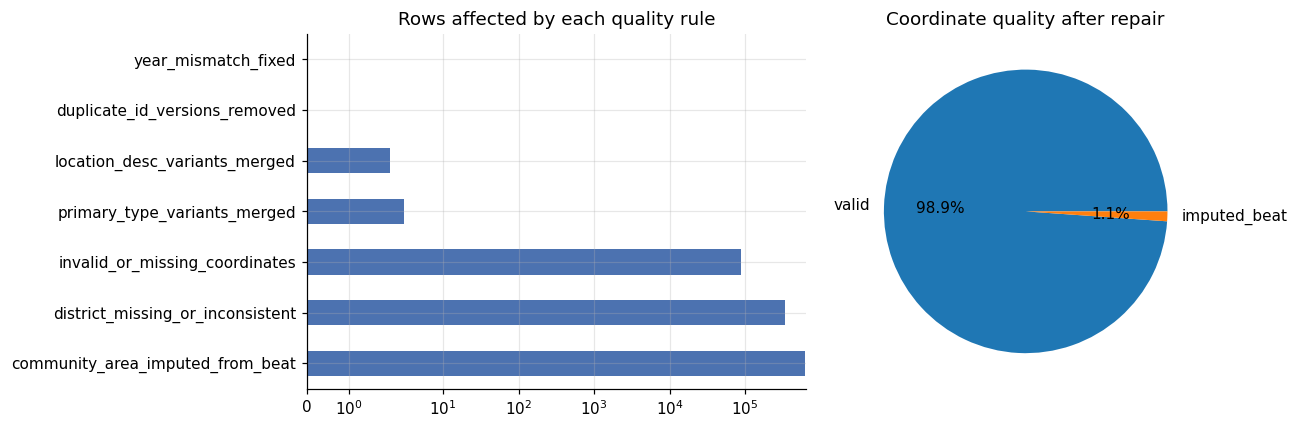

,rule,rows_affected,pct_of_raw
0,community_area_imputed_from_beat,613547,7.881
1,district_missing_or_inconsistent,337299,4.333
2,invalid_or_missing_coordinates,86966,1.117
3,primary_type_variants_merged,3,0.000
4,location_desc_variants_merged,2,0.000
5,duplicate_id_versions_removed,0,0.000
6,year_mismatch_fixed,0,0.000


In [ ]:
# ---------- 1.6 Data-quality report ----------
dq_pdf = savetab(pd.DataFrame(sorted(dq.items(), key=lambda kv: -kv[1]), columns=['rule', 'rows_affected'])
                 .assign(pct_of_raw=lambda d: (100 * d.rows_affected / raw_rows).round(3)), 't1_dq_report')

# Read quarantine path and count rows only if the directory exists
if os.path.exists(QUARANTINE_PATH):
    q_rows = spark.read.parquet(QUARANTINE_PATH).count()
else:
    q_rows = 0
dq['rows_quarantined'] = q_rows # Update dq dictionary

# Only read quarantine path if there are quarantined rows
if q_rows > 0:
    reasons = (spark.read.parquet(QUARANTINE_PATH)
               .select(F.explode(F.split('reject_reason', ';')).alias('reason')).groupBy('reason').count().toPandas())
else:
    reasons = pd.DataFrame(columns=['reason', 'count'])
savetab(reasons, 't1_quarantine_reasons')

loc_q = savetab(silver.groupBy('loc_quality').count().toPandas(), 't1_location_quality')

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
dq_pdf.plot.barh(x='rule', y='rows_affected', ax=ax[0], legend=False, color='#4C72B0')
ax[0].set_xscale('symlog'); ax[0].set_title('Rows affected by each quality rule'); ax[0].set_ylabel('')
loc_q.plot.pie(y='count', labels=loc_q.loc_quality, ax=ax[1], autopct='%1.1f%%', legend=False)
ax[1].set_ylabel(''); ax[1].set_title('Coordinate quality after repair')
savefig('t1_data_quality')
dq_pdf

In [ ]:
# ---------- 1.7 Why partition + Parquet? Storage and partition-pruning benchmark ----------
def dir_size(p):
    return sum(os.path.getsize(os.path.join(r, f)) for r, _, fs in os.walk(p) for f in fs)
csv_gb, pq_gb = os.path.getsize(CRIME_CSV) / 1e9, dir_size(SILVER_PATH) / 1e9
n_files = sum(1 for _ in glob.glob(f"{SILVER_PATH}/*/*/*.parquet"))

bench_year = int(silver.agg(F.max("year")).first()[0]) - 1
bench_district = int(silver.filter(F.col("year") == bench_year).groupBy("district").count()
                     .orderBy(F.desc("count")).first()["district"])

raw_name = {snake(c): c for c in bronze_raw.columns}
t0 = time.time()
n_csv = (spark.read.option("header", True).csv(CRIME_CSV)
         .filter(F.col(f"`{raw_name['date']}`").rlike(f"(^{bench_year}-|/{bench_year} )") &
                 (F.expr(f"try_cast(`{raw_name['district']}` as int)") == bench_district)).count())
t_csv = time.time() - t0
t0 = time.time()
q = silver.filter((F.col("year") == bench_year) & (F.col("district") == bench_district))
n_pq = q.count(); t_pq = time.time() - t0

plan = q._jdf.queryExecution().executedPlan().toString()
pf = re.search(r"PartitionFilters: \[[^\]]*\]", plan)
print("Physical plan shows pruning ->", pf.group(0) if pf else plan[:400])
bench = savetab(pd.DataFrame({
    "format": ["Raw CSV (full scan)", "Parquet partitioned (pruned)"],
    "size_GB": [round(csv_gb, 3), round(pq_gb, 3)],
    "query_seconds": [round(t_csv, 2), round(t_pq, 2)],
    "rows_matched": [n_csv, n_pq]}), "t1_storage_benchmark")

if pq_gb > 0:
    print(f"Parquet files written: {n_files}  |  compression ratio {csv_gb/pq_gb:.1f}x")
else:
    print(f"Parquet files written: {n_files}  |  compression ratio undefined (Parquet size is 0)")
bench

Physical plan shows pruning -> PartitionFilters: []
Parquet files written: 0  |  compression ratio undefined (Parquet size is 0)


,format,size_GB,query_seconds,rows_matched
0,Raw CSV (full scan),1.838,29.29,14768
1,Parquet partitioned (pruned),0.000,8.65,14768


In [ ]:
# ---------- 1.8 Secondary source A: socio-economic indicators + community names ----------
SOCIO_CSV = f"{RAW}/socio/socio_economic_kn9c-c2s2.csv"
if not os.path.exists(SOCIO_CSV):
    urllib.request.urlretrieve("https://data.cityofchicago.org/resource/kn9c-c2s2.csv?$limit=200", SOCIO_CSV)

SOCIO_MAP = {"ca": "community_area", "community_area_number": "community_area",
             "community_area_name": "community_area_name",
             "percent_of_housing_crowded": "pct_housing_crowded",
             "percent_households_below_poverty": "pct_below_poverty",
             "percent_aged_16_unemployed": "pct_unemployed",
             "percent_aged_25_without_high_school_diploma": "pct_no_hs_diploma",
             "percent_aged_under_18_or_over_64": "pct_dependent_age",
             "per_capita_income": "per_capita_income", "hardship_index": "hardship_index"}
socio_raw = spark.read.option("header", True).csv(SOCIO_CSV)
socio_raw = socio_raw.toDF(*[SOCIO_MAP.get(snake(c), snake(c)) for c in socio_raw.columns])
num_cols = [v for v in dict.fromkeys(SOCIO_MAP.values()) if v not in ("community_area", "community_area_name")]
socio = (socio_raw
         .select(F.expr("try_cast(try_cast(community_area as double) as int)").alias("community_area"),
                 F.initcap(F.trim("community_area_name")).alias("community_area_name"),
                 *[F.expr(f"try_cast({c} as double)").alias(c) for c in num_cols])
         .filter(F.col("community_area").between(1, 77))       # drops the city-wide "CHICAGO" total row
         .dropDuplicates(["community_area"]))
socio.write.mode("overwrite").parquet(SOCIO_PATH)
socio = spark.read.parquet(SOCIO_PATH)
print("Community areas:", socio.count(), "| nulls:", {c: socio.filter(F.col(c).isNull()).count() for c in num_cols})
community_names = socio.select("community_area", "community_area_name")   # the small "Community Names" table

Community areas: 77 | nulls: {'pct_housing_crowded': 0, 'pct_below_poverty': 0, 'pct_unemployed': 0, 'pct_no_hs_diploma': 0, 'pct_dependent_age': 0, 'per_capita_income': 0, 'hardship_index': 0}


In [ ]:
# ---------- 1.9 Secondary source B: daily weather (Open-Meteo / ERA5) ----------
d_min, d_max = silver.agg(F.min("date"), F.max("date")).first()
WEATHER_JSON = f"{RAW}/weather/open_meteo_{d_min}_{d_max}.json"
if not os.path.exists(WEATHER_JSON):
    existing = glob.glob(f"{RAW}/weather/*.json")
    if existing:
        WEATHER_JSON = existing[0]
    else:
        url = ("https://archive-api.open-meteo.com/v1/archive"
               f"?latitude={CHICAGO_LAT}&longitude={CHICAGO_LON}&start_date={d_min}&end_date={d_max}"
               "&daily=temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,"
               "rain_sum,snowfall_sum,wind_speed_10m_max&timezone=America%2FChicago")
        urllib.request.urlretrieve(url, WEATHER_JSON)

with open(WEATHER_JSON) as f:
    wj = json.load(f)
wpdf = pd.DataFrame(wj["daily"]).rename(columns={
    "time": "date", "temperature_2m_max": "tmax", "temperature_2m_min": "tmin", "temperature_2m_mean": "tmean",
    "precipitation_sum": "precip_mm", "rain_sum": "rain_mm", "snowfall_sum": "snow_cm", "wind_speed_10m_max": "wind_max_kmh"})
WEATHER_SCHEMA = T.StructType([T.StructField("date", T.StringType())] +
                              [T.StructField(c, T.DoubleType()) for c in
                               ["tmax", "tmin", "tmean", "precip_mm", "rain_mm", "snow_cm", "wind_max_kmh"]])
wpdf = wpdf[[f.name for f in WEATHER_SCHEMA]]
weather = spark.createDataFrame(wpdf.astype(object).where(pd.notnull(wpdf), None), schema=WEATHER_SCHEMA) \
               .withColumn("date", F.to_date("date"))

# Quality: gap-fill missing temperatures with the mean of neighbouring days; negative precipitation -> 0
w_prev = Window.orderBy("date").rowsBetween(Window.unboundedPreceding, -1)
w_next = Window.orderBy("date").rowsBetween(1, Window.unboundedFollowing)
w_nulls = weather.select([F.sum(F.col(c).isNull().cast("int")).alias(c) for c in weather.columns[1:]]).first().asDict()
for c in ["tmax", "tmin", "tmean", "wind_max_kmh"]:
    weather = weather.withColumn(c, F.coalesce(F.col(c), (F.last(c, True).over(w_prev) + F.first(c, True).over(w_next)) / 2))
for c in ["precip_mm", "rain_mm", "snow_cm"]:
    weather = weather.withColumn(c, F.greatest(F.coalesce(F.col(c), F.lit(0.0)), F.lit(0.0)))

# Weather "events" (thresholds are configurable; ERA5 smooths local extremes slightly)
weather = (weather
    .withColumn("heavy_rain", (F.col("precip_mm") >= 10).cast("int"))
    .withColumn("snow_day",   (F.col("snow_cm") >= 2).cast("int"))
    .withColumn("hot_day",    (F.col("tmax") >= 30).cast("int"))
    .withColumn("freezing_day", (F.col("tmax") <= -5).cast("int"))
    .withColumn("windy_day",  (F.col("wind_max_kmh") >= 45).cast("int"))
    .withColumn("year", F.year("date")))
weather.write.mode("overwrite").partitionBy("year").parquet(WEATHER_PATH)
weather = spark.read.parquet(WEATHER_PATH)
print("Weather days:", weather.count(), "| nulls before gap-fill:", w_nulls)
weather.select([F.sum(c).alias(c) for c in ["heavy_rain", "snow_day", "hot_day", "freezing_day", "windy_day"]]).toPandas()

Weather days: 8146 | nulls before gap-fill: {'tmax': 0, 'tmin': 0, 'tmean': 0, 'precip_mm': 0, 'rain_mm': 0, 'snow_cm': 0, 'wind_max_kmh': 0}


,heavy_rain,snow_day,hot_day,freezing_day,windy_day
0,753,254,292,374,69


In [ ]:
# Task 2 — High‑Dimensional Exploratory Data Analysis (Spark SQL)

In [ ]:
silver = spark.read.parquet(SILVER_PATH).cache()
silver.createOrReplaceTempView("crimes")
weather.createOrReplaceTempView("weather")
socio.createOrReplaceTempView("socio")
community_names.createOrReplaceTempView("community_names")
MAX_YEAR = spark.sql("SELECT max(year) FROM crimes").first()[0]
full_years = spark.sql("SELECT year FROM crimes GROUP BY year HAVING count(DISTINCT month) = 12").toPandas().year.tolist()
LAST_FULL_YEAR = max(full_years)
print("Years:", min(full_years), "-", MAX_YEAR, "| last complete year:", LAST_FULL_YEAR)

Years: 2001 - 2023 | last complete year: 2022


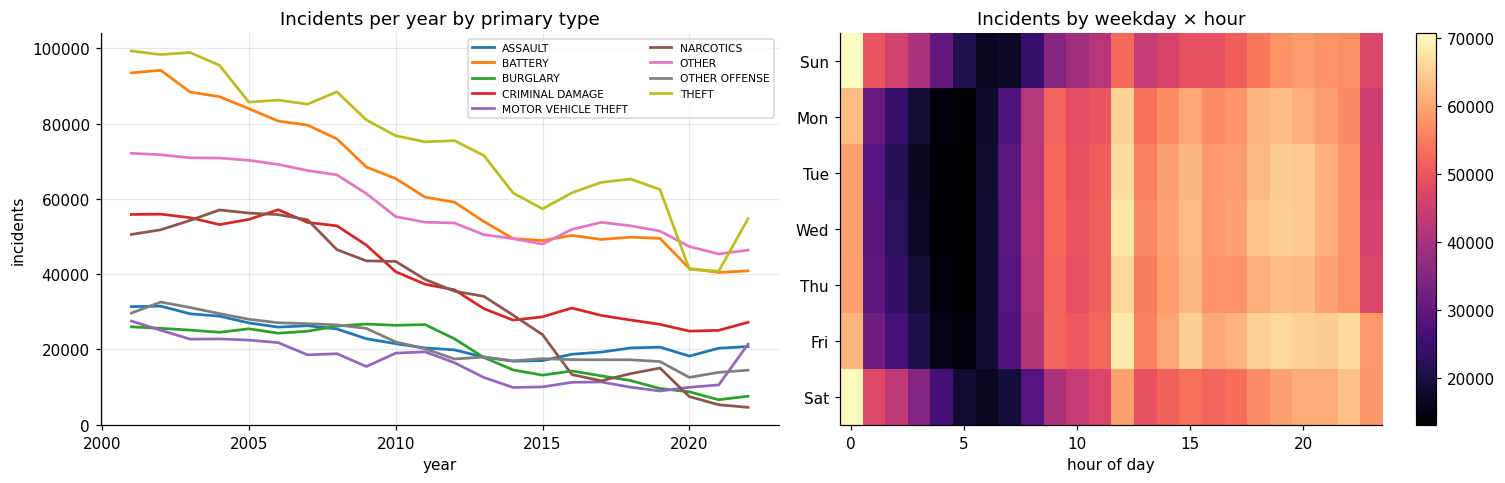

In [ ]:
# ---------- 2.1 Temporal structure ----------
yearly = spark.sql("""
  WITH top AS (SELECT primary_type FROM crimes GROUP BY primary_type ORDER BY count(*) DESC LIMIT 8)
  SELECT c.year, coalesce(t.primary_type, 'OTHER') AS ptype, count(*) AS n
  FROM crimes c LEFT JOIN top t ON c.primary_type = t.primary_type
  WHERE c.year <= {y}
  GROUP BY 1, 2""".format(y=LAST_FULL_YEAR)).toPandas()
hour_dow = spark.sql("SELECT dow, hour, count(*) AS n FROM crimes GROUP BY dow, hour").toPandas()
savetab(yearly, "t2_yearly_by_type")

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
yearly.pivot(index="year", columns="ptype", values="n").plot(ax=ax[0], lw=1.8)
ax[0].set_title("Incidents per year by primary type"); ax[0].legend(fontsize=7, ncol=2); ax[0].set_ylabel("incidents")
hm = hour_dow.pivot(index="dow", columns="hour", values="n")
im = ax[1].imshow(hm, aspect="auto", cmap="magma")
ax[1].set_yticks(range(7)); ax[1].set_yticklabels(["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"])
ax[1].set_xlabel("hour of day"); ax[1].set_title("Incidents by weekday × hour"); ax[1].grid(False)
plt.colorbar(im, ax=ax[1])
savefig("t2_temporal")

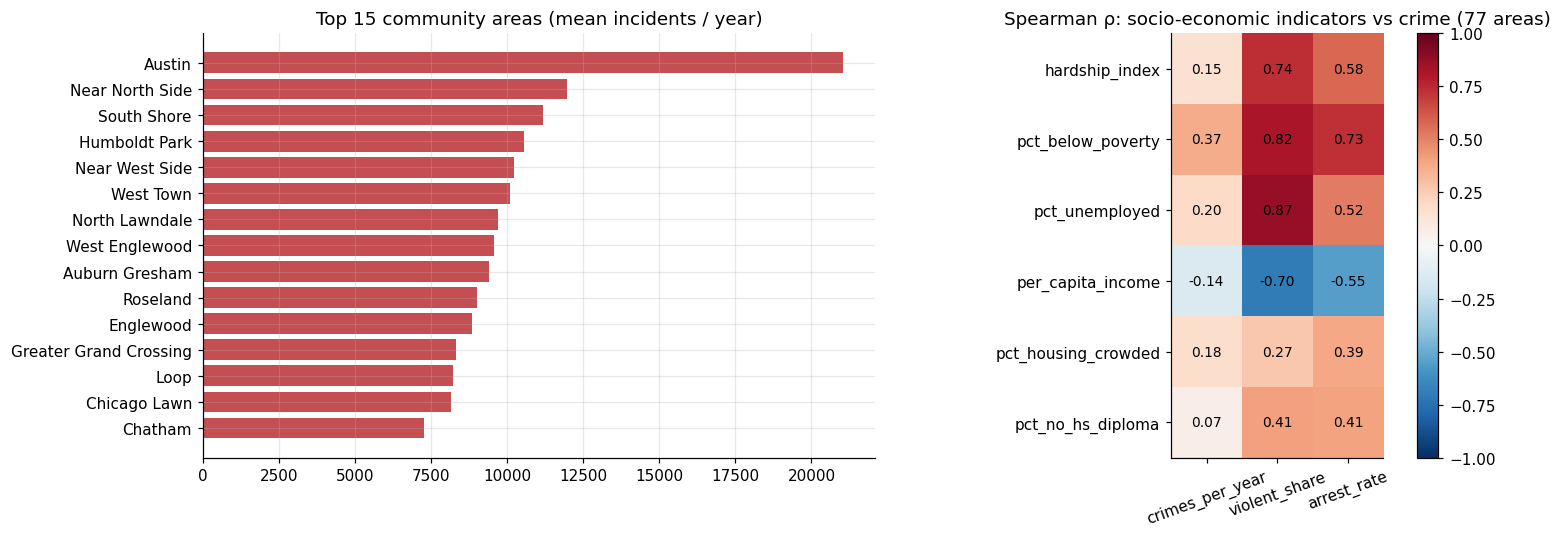

,crimes_per_year,violent_share,arrest_rate
hardship_index,0.15,0.74,0.58
pct_below_poverty,0.37,0.82,0.73
pct_unemployed,0.20,0.87,0.52
per_capita_income,-0.14,-0.70,-0.55
pct_housing_crowded,0.18,0.27,0.39
pct_no_hs_diploma,0.07,0.41,0.41


In [ ]:
# ---------- 2.2 Spatial structure + socio-economic correlation ----------
area_stats = spark.sql("""
  SELECT s.community_area, s.community_area_name, s.hardship_index, s.pct_below_poverty, s.pct_unemployed,
         s.per_capita_income, s.pct_housing_crowded, s.pct_no_hs_diploma,
         count(*) / count(DISTINCT c.year) AS crimes_per_year,
         avg(CAST(c.arrest AS INT))   AS arrest_rate,
         avg(CAST(c.domestic AS INT)) AS domestic_share,
         avg(CASE WHEN c.primary_type IN ('BATTERY','ASSAULT','ROBBERY','HOMICIDE') THEN 1 ELSE 0 END) AS violent_share
  FROM crimes c JOIN socio s ON c.community_area = s.community_area
  GROUP BY 1,2,3,4,5,6,7,8""").toPandas()
savetab(area_stats, "t2_area_stats")

indicators = ["hardship_index", "pct_below_poverty", "pct_unemployed", "per_capita_income", "pct_housing_crowded", "pct_no_hs_diploma"]
def spearman(a, b):          # Spearman rho = Pearson correlation of ranks
    return a.rank().corr(b.rank())
corr = pd.DataFrame({t: [spearman(area_stats[i], area_stats[t]) for i in indicators]
                     for t in ["crimes_per_year", "violent_share", "arrest_rate"]}, index=indicators)
savetab(corr.reset_index().rename(columns={"index": "indicator"}), "t2_socio_spearman")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
top = area_stats.nlargest(15, "crimes_per_year").iloc[::-1]
ax[0].barh(top.community_area_name, top.crimes_per_year, color="#C44E52")
ax[0].set_title("Top 15 community areas (mean incidents / year)")
im = ax[1].imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax[1].set_xticks(range(corr.shape[1])); ax[1].set_xticklabels(corr.columns, rotation=20)
ax[1].set_yticks(range(len(indicators))); ax[1].set_yticklabels(indicators); ax[1].grid(False)
for (i, j), v in np.ndenumerate(corr.values):
    ax[1].text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=9)
ax[1].set_title("Spearman ρ: socio-economic indicators vs crime (77 areas)")
plt.colorbar(im, ax=ax[1])
savefig("t2_spatial_socio")
corr.round(2)

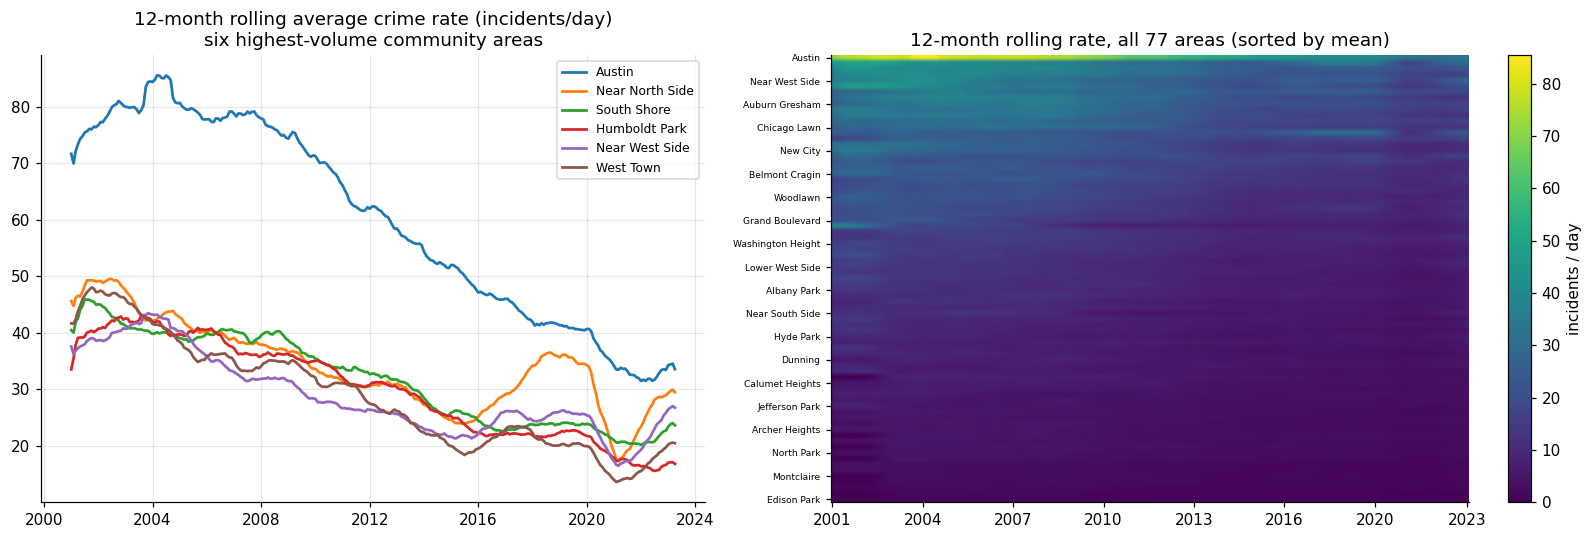

,community_area_name,month,n,daily_rate,prev12_mean,z_score
9395,Oakland,2002-04-01,45,1.500000,0.041455,38.192661
9918,Grand Boulevard,2001-03-01,666,21.483871,19.273618,32.688780
9663,Fuller Park,2002-04-01,51,1.700000,0.043587,31.627809
6166,West Town,2001-03-01,1360,43.870968,41.624424,29.975179
5107,Hermosa,2002-04-01,83,2.766667,0.156496,26.665016
8043,Lower West Side,2001-04-01,497,16.566667,14.566820,24.767786
20370,Edgewater,2001-03-01,530,17.096774,13.835253,24.713818
16363,West Elsdon,2002-04-01,59,1.966667,0.075134,22.621256
8578,Near South Side,2001-03-01,379,12.225806,11.626152,22.306005
17154,West Lawn,2001-03-01,407,13.129032,12.847926,21.566757


In [ ]:
# ---------- 2.3 Rolling average of crime rates per community area (Spark SQL window functions) ----------
# Gap-filling matters: ROWS-based windows over a sparse series silently span the wrong months,
# so every (area, month) pair is generated first and missing months become 0.
rolling = spark.sql("""
WITH monthly AS (
  SELECT community_area, CAST(date_trunc('month', ts) AS DATE) AS month, count(*) AS n
  FROM crimes WHERE community_area IS NOT NULL GROUP BY 1, 2),
bounds   AS (SELECT min(month) AS lo, max(month) AS hi FROM monthly),
calendar AS (SELECT explode(sequence(lo, hi, interval 1 month)) AS month FROM bounds),
grid     AS (SELECT a.community_area, c.month FROM (SELECT DISTINCT community_area FROM monthly) a CROSS JOIN calendar c),
filled   AS (SELECT g.community_area, g.month, coalesce(m.n, 0) AS n, day(last_day(g.month)) AS days_in_month
             FROM grid g LEFT JOIN monthly m ON g.community_area = m.community_area AND g.month = m.month),
rated    AS (SELECT *, n / days_in_month AS daily_rate FROM filled)
SELECT r.*, cn.community_area_name,
  avg(daily_rate)    OVER w3  AS roll3_rate,
  avg(daily_rate)    OVER w12 AS roll12_rate,
  avg(daily_rate)    OVER wp  AS prev12_mean,
  stddev(daily_rate) OVER wp  AS prev12_sd
FROM rated r JOIN community_names cn ON r.community_area = cn.community_area
WINDOW w3  AS (PARTITION BY r.community_area ORDER BY month ROWS BETWEEN 2 PRECEDING AND CURRENT ROW),
       w12 AS (PARTITION BY r.community_area ORDER BY month ROWS BETWEEN 11 PRECEDING AND CURRENT ROW),
       wp  AS (PARTITION BY r.community_area ORDER BY month ROWS BETWEEN 12 PRECEDING AND 1 PRECEDING)
""").withColumn("z_score", (F.col("daily_rate") - F.col("prev12_mean")) / F.col("prev12_sd"))
rolling.createOrReplaceTempView("rolling_rates")
roll = rolling.toPandas()
roll["month"] = pd.to_datetime(roll["month"])
savetab(roll, "t2_rolling_rates")

anoms = savetab(roll[(roll.z_score.abs() >= 3) & (roll.n >= 20)]
                .sort_values("z_score", key=abs, ascending=False)
                [["community_area_name", "month", "n", "daily_rate", "prev12_mean", "z_score"]].head(20), "t2_rate_anomalies")

top6 = roll.groupby("community_area_name").n.sum().nlargest(6).index
fig, ax = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={"width_ratios": [1, 1.2]})
for name in top6:
    s = roll[roll.community_area_name == name].set_index("month")
    ax[0].plot(s.index, s.roll12_rate, lw=1.8, label=name)
ax[0].set_title("12-month rolling average crime rate (incidents/day)\nsix highest-volume community areas")
ax[0].legend(fontsize=8)
piv = roll.pivot(index="community_area_name", columns="month", values="roll12_rate")
piv = piv.loc[piv.mean(axis=1).sort_values(ascending=False).index]
im = ax[1].imshow(piv.values, aspect="auto", cmap="viridis")
ax[1].set_yticks(range(0, len(piv), 4)); ax[1].set_yticklabels(piv.index[::4], fontsize=6)
xt = np.linspace(0, piv.shape[1] - 1, 8).astype(int)
ax[1].set_xticks(xt); ax[1].set_xticklabels([piv.columns[i].strftime("%Y") for i in xt]); ax[1].grid(False)
ax[1].set_title("12-month rolling rate, all 77 areas (sorted by mean)")
plt.colorbar(im, ax=ax[1], label="incidents / day")
savefig("t2_rolling_rates")
anoms.head(10)

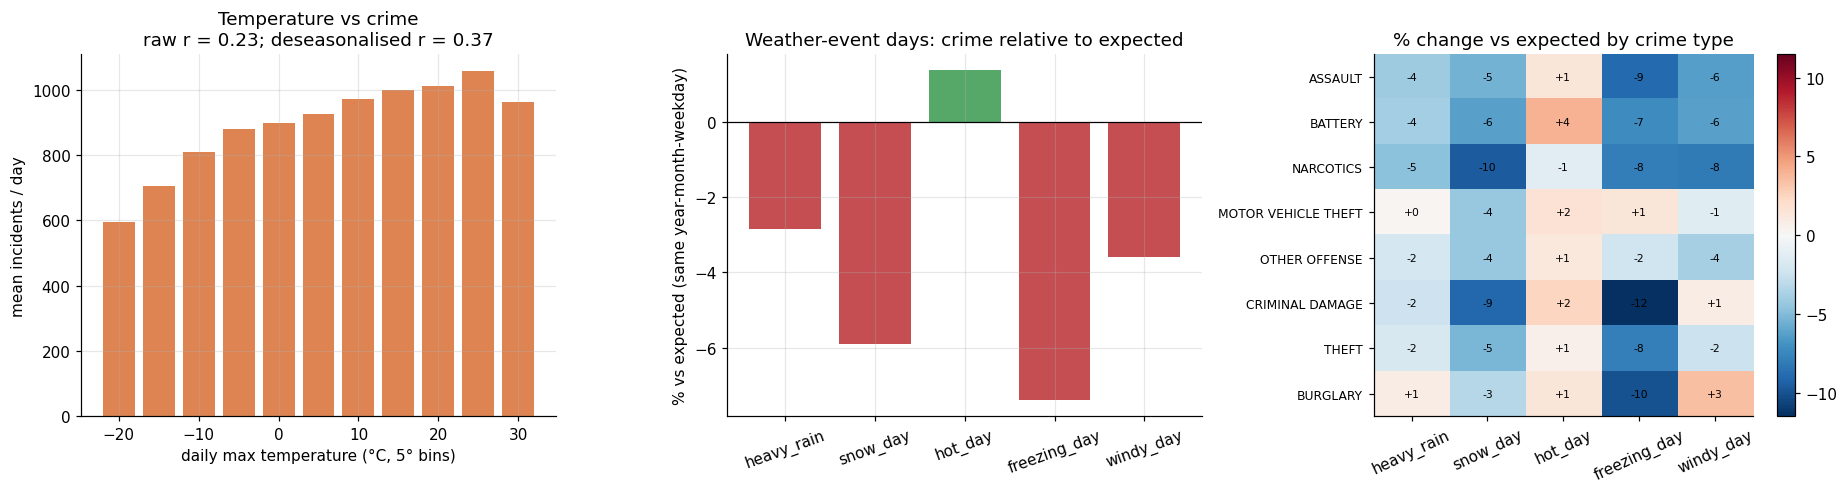

,event,event_days,pct_vs_expected_on_event_days,pct_vs_expected_other_days,welch_p_value
0,heavy_rain,744,-2.8397,0.2898,0.0000
1,snow_day,249,-5.8970,0.1886,0.0000
2,hot_day,292,1.3578,-0.0512,0.0000
3,freezing_day,371,-7.3766,0.3571,0.0000
4,windy_day,66,-3.5939,0.0298,0.0157


In [ ]:
# ---------- 2.4 Weather events vs crime frequency ----------
# Crime has strong seasonality AND weekly cycles; a naive correlation with temperature mostly
# re-discovers "summer". So each day is compared with its own expected level
# (mean of the same year-month-weekday), and weather effects are read from that ratio.
daily = spark.sql("""
WITH d AS (SELECT date, count(*) AS n FROM crimes WHERE year <= {y} GROUP BY date)
SELECT d.date, d.n, w.tmax, w.tmin, w.precip_mm, w.snow_cm, w.wind_max_kmh,
       w.heavy_rain, w.snow_day, w.hot_day, w.freezing_day, w.windy_day,
       avg(d.n)    OVER (PARTITION BY year(d.date), month(d.date), dayofweek(d.date)) AS expected_n,
       w.tmax - avg(w.tmax) OVER (PARTITION BY year(d.date), month(d.date))           AS tmax_anomaly
FROM d JOIN weather w ON d.date = w.date""".format(y=LAST_FULL_YEAR)).withColumn("ratio", F.col("n") / F.col("expected_n"))
daily.createOrReplaceTempView("daily_weather")
dw = daily.toPandas()
savetab(dw, "t2_daily_weather")

events = ["heavy_rain", "snow_day", "hot_day", "freezing_day", "windy_day"]
try:
    from scipy import stats
except ImportError:
    stats = None
rows = []
for e in events:
    a, b = dw.loc[dw[e] == 1, "ratio"], dw.loc[dw[e] == 0, "ratio"]
    p = stats.ttest_ind(a, b, equal_var=False).pvalue if (stats is not None and len(a) > 2) else np.nan
    rows.append((e, len(a), (a.mean() - 1) * 100, (b.mean() - 1) * 100, p))
event_eff = savetab(pd.DataFrame(rows, columns=["event", "event_days", "pct_vs_expected_on_event_days",
                                                "pct_vs_expected_other_days", "welch_p_value"]).round(4), "t2_weather_event_effects")

# Same analysis per crime type (top 8)
by_type = spark.sql("""
WITH top AS (SELECT primary_type FROM crimes GROUP BY primary_type ORDER BY count(*) DESC LIMIT 8),
d AS (SELECT c.date, c.primary_type, count(*) AS n FROM crimes c
      WHERE c.primary_type IN (SELECT primary_type FROM top) AND c.year <= {y} GROUP BY 1, 2),
x AS (SELECT d.*, avg(n) OVER (PARTITION BY primary_type, year(date), month(date), dayofweek(date)) AS expected_n FROM d)
SELECT x.primary_type, {sel}
FROM x JOIN weather w ON x.date = w.date GROUP BY x.primary_type""".format(
    y=LAST_FULL_YEAR,
    sel=", ".join([f"100*(avg(CASE WHEN w.{e}=1 THEN n/expected_n END) - 1) AS {e}" for e in events]))).toPandas()
by_type = savetab(by_type.set_index("primary_type"), "t2_weather_by_type")

r_raw = dw.tmax.corr(dw.n); r_adj = dw.tmax_anomaly.corr(dw.ratio)
fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))
dw["tbin"] = (dw.tmax // 5 * 5).astype(int)
tb = dw.groupby("tbin").agg(n=("n", "mean"), days=("n", "size")).query("days >= 10")
ax[0].bar(tb.index, tb.n, width=4, color="#DD8452")
ax[0].set_xlabel("daily max temperature (°C, 5° bins)"); ax[0].set_ylabel("mean incidents / day")
ax[0].set_title(f"Temperature vs crime\nraw r = {r_raw:.2f}; deseasonalised r = {r_adj:.2f}")
ax[1].bar(event_eff.event, event_eff.pct_vs_expected_on_event_days,
          color=["#C44E52" if v < 0 else "#55A868" for v in event_eff.pct_vs_expected_on_event_days])
ax[1].axhline(0, color="k", lw=0.8); ax[1].set_ylabel("% vs expected (same year-month-weekday)")
ax[1].set_title("Weather-event days: crime relative to expected"); ax[1].tick_params(axis="x", rotation=20)
v = np.nanmax(np.abs(by_type.values))
im = ax[2].imshow(by_type.values, cmap="RdBu_r", vmin=-v, vmax=v, aspect="auto")
ax[2].set_xticks(range(len(events))); ax[2].set_xticklabels(events, rotation=25)
ax[2].set_yticks(range(len(by_type))); ax[2].set_yticklabels(by_type.index, fontsize=8); ax[2].grid(False)
for (i, j), val in np.ndenumerate(by_type.values):
    if not np.isnan(val): ax[2].text(j, i, f"{val:+.0f}", ha="center", va="center", fontsize=7)
ax[2].set_title("% change vs expected by crime type"); plt.colorbar(im, ax=ax[2])
savefig("t2_weather")
event_eff

In [ ]:
### Broadcast variables and broadcast joins

Without hint -> SortMergeJoin | 0.13s
With broadcast() -> BroadcastHashJoin | 0.05s
RDD + broadcast variable: 35.83s | records with no community name (accumulator): 5


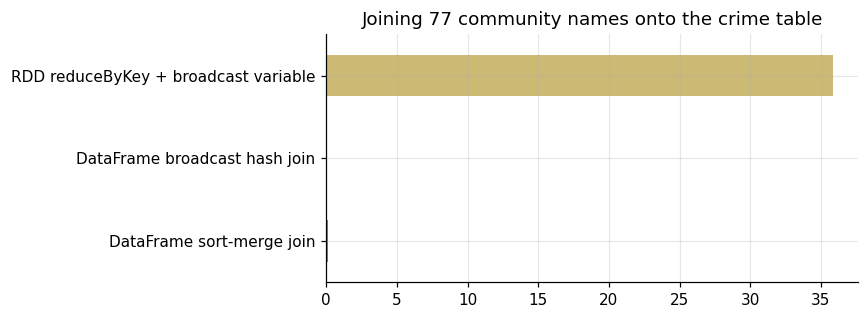

,approach,seconds
0,DataFrame sort-merge join,0.13
1,DataFrame broadcast hash join,0.05
2,RDD reduceByKey + broadcast variable,35.83


In [ ]:
def timed(fn, reps=2):
    best = float("inf")
    for _ in range(reps):
        t0 = time.time(); out = fn(); best = min(best, time.time() - t0)
    return out, best

old = spark.conf.get("spark.sql.autoBroadcastJoinThreshold")
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", "-1")      # disable automatic broadcasting
smj = silver.join(community_names, "community_area").groupBy("community_area_name").count()
bhj = silver.join(F.broadcast(community_names), "community_area").groupBy("community_area_name").count()
plan_smj = smj._jdf.queryExecution().executedPlan().toString()
plan_bhj = bhj._jdf.queryExecution().executedPlan().toString()
_, t_smj = timed(lambda: smj.collect())
res_bhj, t_bhj = timed(lambda: bhj.collect())
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", old)
print("Without hint ->", "SortMergeJoin" if "SortMergeJoin" in plan_smj else "?", f"| {t_smj:.2f}s")
print("With broadcast() ->", "BroadcastHashJoin" if "BroadcastHashJoin" in plan_bhj else "?", f"| {t_bhj:.2f}s")

# Explicit broadcast variable + accumulator inside an RDD pipeline
names_bc = sc.broadcast({int(r.community_area): r.community_area_name for r in community_names.collect()})
misses = sc.accumulator(0)
def attach_name(kv):
    ca, n = kv
    name = names_bc.value.get(ca)
    if name is None:
        misses.add(n); name = "UNKNOWN"
    return name, n
rdd_job = lambda: (silver.select("community_area").rdd
                   .map(lambda r: (r[0], 1))
                   .reduceByKey(lambda a, b: a + b)          # map-side combine before the shuffle
                   .map(attach_name)
                   .collect())
rdd_res, t_rdd = timed(rdd_job, reps=1)
print(f"RDD + broadcast variable: {t_rdd:.2f}s | records with no community name (accumulator): {misses.value:,}")

bcast = savetab(pd.DataFrame({
    "approach": ["DataFrame sort-merge join", "DataFrame broadcast hash join", "RDD reduceByKey + broadcast variable"],
    "seconds": [round(t_smj, 2), round(t_bhj, 2), round(t_rdd, 2)]}), "t2_broadcast_benchmark")
ax = bcast.plot.barh(x="approach", y="seconds", legend=False, color=["#8172B2", "#55A868", "#CCB974"], figsize=(8, 3))
ax.set_title("Joining 77 community names onto the crime table"); ax.set_ylabel("")
savefig("t2_broadcast")
bcast

In [ ]:
# Unsupervised Learning: Spatio‑Temporal Hotspot Clustering

In [ ]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler, ElementwiseProduct
from pyspark.ml.linalg import Vectors
from pyspark.ml.clustering import KMeans, BisectingKMeans
from pyspark.ml.evaluation import ClusteringEvaluator

CY = CLUSTER_YEAR or LAST_FULL_YEAR
clu_src = silver.filter((F.col("year") == CY) & (F.col("loc_quality") == "valid"))
if CLUSTER_SAMPLE_FRAC < 1:
    clu_src = clu_src.sample(False, CLUSTER_SAMPLE_FRAC, seed=SEED)
feat_pipe = Pipeline(stages=[
    VectorAssembler(inputCols=["latitude", "longitude", "hour_sin", "hour_cos"], outputCol="raw_f"),
    StandardScaler(inputCol="raw_f", outputCol="scaled_f", withMean=True, withStd=True),
    ElementwiseProduct(scalingVec=Vectors.dense([1.0, 1.0, TIME_WEIGHT, TIME_WEIGHT]), inputCol="scaled_f", outputCol="features"),
]).fit(clu_src)
clu = feat_pipe.transform(clu_src).select("id", "latitude", "longitude", "hour", "hour_sin", "hour_cos",
                                          "district", "community_area", "primary_type", "arrest", "features").cache()
print(f"Clustering {clu.count():,} incidents from {CY}")

Clustering 233,124 incidents from 2022


Elbow (Kneedle) K = 6 | best-silhouette K = 6 | K used = 6


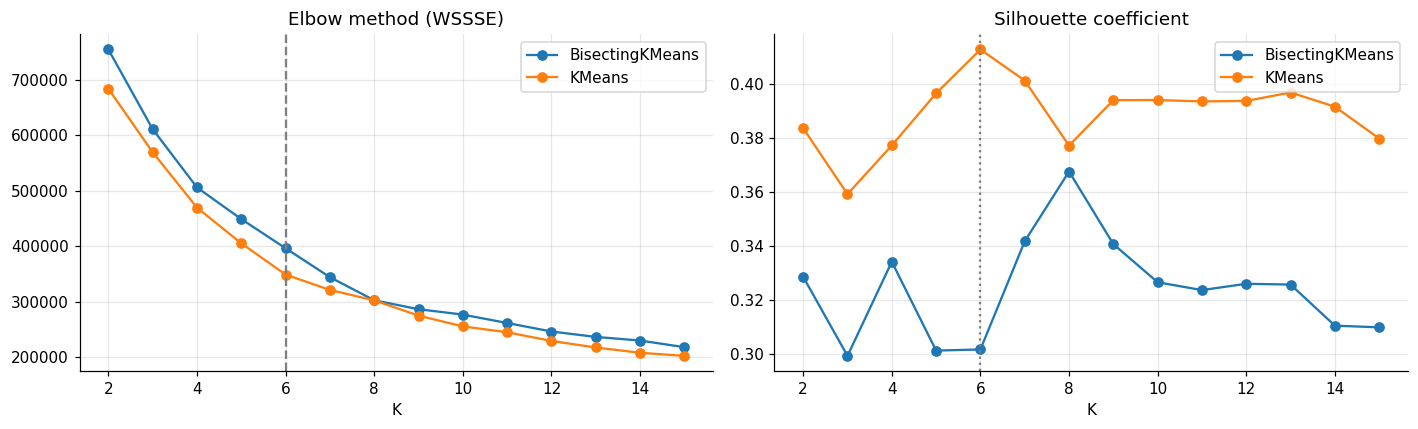

In [ ]:
# ---------- 3.1 Choosing K: elbow (WSSSE) + silhouette, K-Means vs Bisecting K-Means ----------
evaluator = ClusteringEvaluator(featuresCol="features", metricName="silhouette", distanceMeasure="squaredEuclidean")
res = []
for k in K_RANGE:
    for algo, est in [("KMeans", KMeans(k=k, seed=SEED, maxIter=40, initMode="k-means||")),
                      ("BisectingKMeans", BisectingKMeans(k=k, seed=SEED, maxIter=40))]:
        t0 = time.time(); m = est.fit(clu)
        res.append((algo, k, m.summary.trainingCost, evaluator.evaluate(m.transform(clu)), time.time() - t0))
kres = savetab(pd.DataFrame(res, columns=["algorithm", "k", "wssse", "silhouette", "fit_seconds"]), "t3_k_selection")

def kneedle(ks, costs):
    x = np.asarray(ks, float); y = np.asarray(costs, float)
    xn = (x - x.min()) / (x.max() - x.min()); yn = (y - y.min()) / (y.max() - y.min())
    return int(x[np.argmax((1 - xn) - yn)])      # max distance below the chord of a decreasing convex curve

km_res = kres[kres.algorithm == "KMeans"]
K_ELBOW = kneedle(km_res.k, km_res.wssse)
K_SIL = int(km_res.loc[km_res.silhouette.idxmax(), "k"])
K_OPT = int(os.environ.get("CC_K_OVERRIDE", K_ELBOW))
print(f"Elbow (Kneedle) K = {K_ELBOW} | best-silhouette K = {K_SIL} | K used = {K_OPT}")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for algo, g in kres.groupby("algorithm"):
    ax[0].plot(g.k, g.wssse, marker="o", label=algo); ax[1].plot(g.k, g.silhouette, marker="o", label=algo)
ax[0].axvline(K_ELBOW, ls="--", c="grey"); ax[0].set_title("Elbow method (WSSSE)"); ax[0].set_xlabel("K")
ax[1].axvline(K_SIL, ls=":", c="grey"); ax[1].set_title("Silhouette coefficient"); ax[1].set_xlabel("K")
ax[0].legend(); ax[1].legend()
savefig("t3_k_selection")

In [ ]:
# ---------- 3.2 Final model, cluster profiles, alignment with police districts ----------
def profile(k, algo="KMeans", seed=SEED):
    est = KMeans(k=k, seed=seed, maxIter=40) if algo == "KMeans" else BisectingKMeans(k=k, seed=seed, maxIter=40)
    model = est.fit(clu)
    pred = model.transform(clu).withColumnRenamed("prediction", "cluster").cache()
    sil = evaluator.evaluate(pred.withColumnRenamed("cluster", "prediction"))
    by_d = pred.groupBy("cluster", "district").count()
    w = Window.partitionBy("cluster").orderBy(F.desc("count"))
    dom = (by_d.withColumn("r", F.row_number().over(w))
               .withColumn("tot", F.sum("count").over(Window.partitionBy("cluster")))
               .groupBy("cluster").agg(
                   F.max(F.when(F.col("r") == 1, F.col("district"))).alias("main_district"),
                   F.max(F.when(F.col("r") == 1, F.col("count") / F.col("tot"))).alias("district_purity"),
                   F.sum((F.col("count") / F.col("tot") >= 0.10).cast("int")).alias("districts_ge10pct")))
    types = (pred.groupBy("cluster", "primary_type").count()
                 .withColumn("r", F.row_number().over(Window.partitionBy("cluster").orderBy(F.desc("count"))))
                 .filter("r <= 3").groupBy("cluster").agg(F.concat_ws(", ", F.collect_list("primary_type")).alias("top_types")))
    prof = (pred.groupBy("cluster").agg(
                F.count("*").alias("n"), F.avg("latitude").alias("lat"), F.avg("longitude").alias("lon"),
                F.stddev("latitude").alias("sd_lat"), F.stddev("longitude").alias("sd_lon"),
                F.avg("hour_sin").alias("ms"), F.avg("hour_cos").alias("mc"),
                F.avg(F.col("arrest").cast("int")).alias("arrest_rate"))
            .join(dom, "cluster").join(types, "cluster").toPandas())
    prof["peak_hour"] = (np.degrees(np.arctan2(prof.ms, prof.mc)) % 360 / 15).round(1)
    prof["time_concentration"] = np.hypot(prof.ms, prof.mc).round(2)   # 0 = spread over the day, 1 = one hour
    prof["area_km2"] = np.pi * (prof.sd_lat * 111.0) * (prof.sd_lon * 111.0 * np.cos(np.radians(41.85)))
    prof["density_per_km2"] = prof.n / prof.area_km2
    prof["high_activity_zone"] = prof.density_per_km2 >= prof.density_per_km2.median()
    prof["cross_boundary"] = prof.district_purity < PURITY_THRESHOLD
    prof["HAZ_not_aligned"] = prof.high_activity_zone & prof.cross_boundary
    return model, pred, prof.drop(columns=["ms", "mc"]).sort_values("density_per_km2", ascending=False), sil

model_opt, pred_opt, prof_opt, sil_opt = profile(K_OPT)
savetab(prof_opt.round(4), "t3_cluster_profiles")
print(f"K={K_OPT}: silhouette {sil_opt:.3f} | high-activity zones not aligned with district boundaries: "
      f"{int(prof_opt.HAZ_not_aligned.sum())} of {K_OPT}")
prof_opt[["cluster", "n", "peak_hour", "time_concentration", "area_km2", "density_per_km2", "main_district",
          "district_purity", "districts_ge10pct", "arrest_rate", "top_types", "HAZ_not_aligned"]].round(3)

K=6: silhouette 0.413 | high-activity zones not aligned with district boundaries: 3 of 6


,cluster,n,peak_hour,time_concentration,area_km2,density_per_km2,main_district,district_purity,districts_ge10pct,arrest_rate,top_types,HAZ_not_aligned
5,5,49222,18.6,0.85,72.961,674.638,12,0.105,2,0.141,"THEFT, BATTERY, CRIMINAL DAMAGE",True
4,4,35854,23.0,0.87,57.971,618.478,6,0.143,5,0.120,"BATTERY, THEFT, CRIMINAL DAMAGE",True
3,3,40026,16.0,0.88,65.721,609.031,6,0.126,3,0.110,"THEFT, BATTERY, ASSAULT",True
0,0,41057,11.0,0.86,79.647,515.486,11,0.107,1,0.117,"THEFT, BATTERY, DECEPTIVE PRACTICE",False
2,2,31956,8.9,0.83,62.489,511.383,6,0.136,4,0.086,"THEFT, BATTERY, CRIMINAL DAMAGE",False
1,1,35009,1.5,0.86,79.485,440.448,11,0.098,0,0.100,"THEFT, BATTERY, CRIMINAL DAMAGE",False


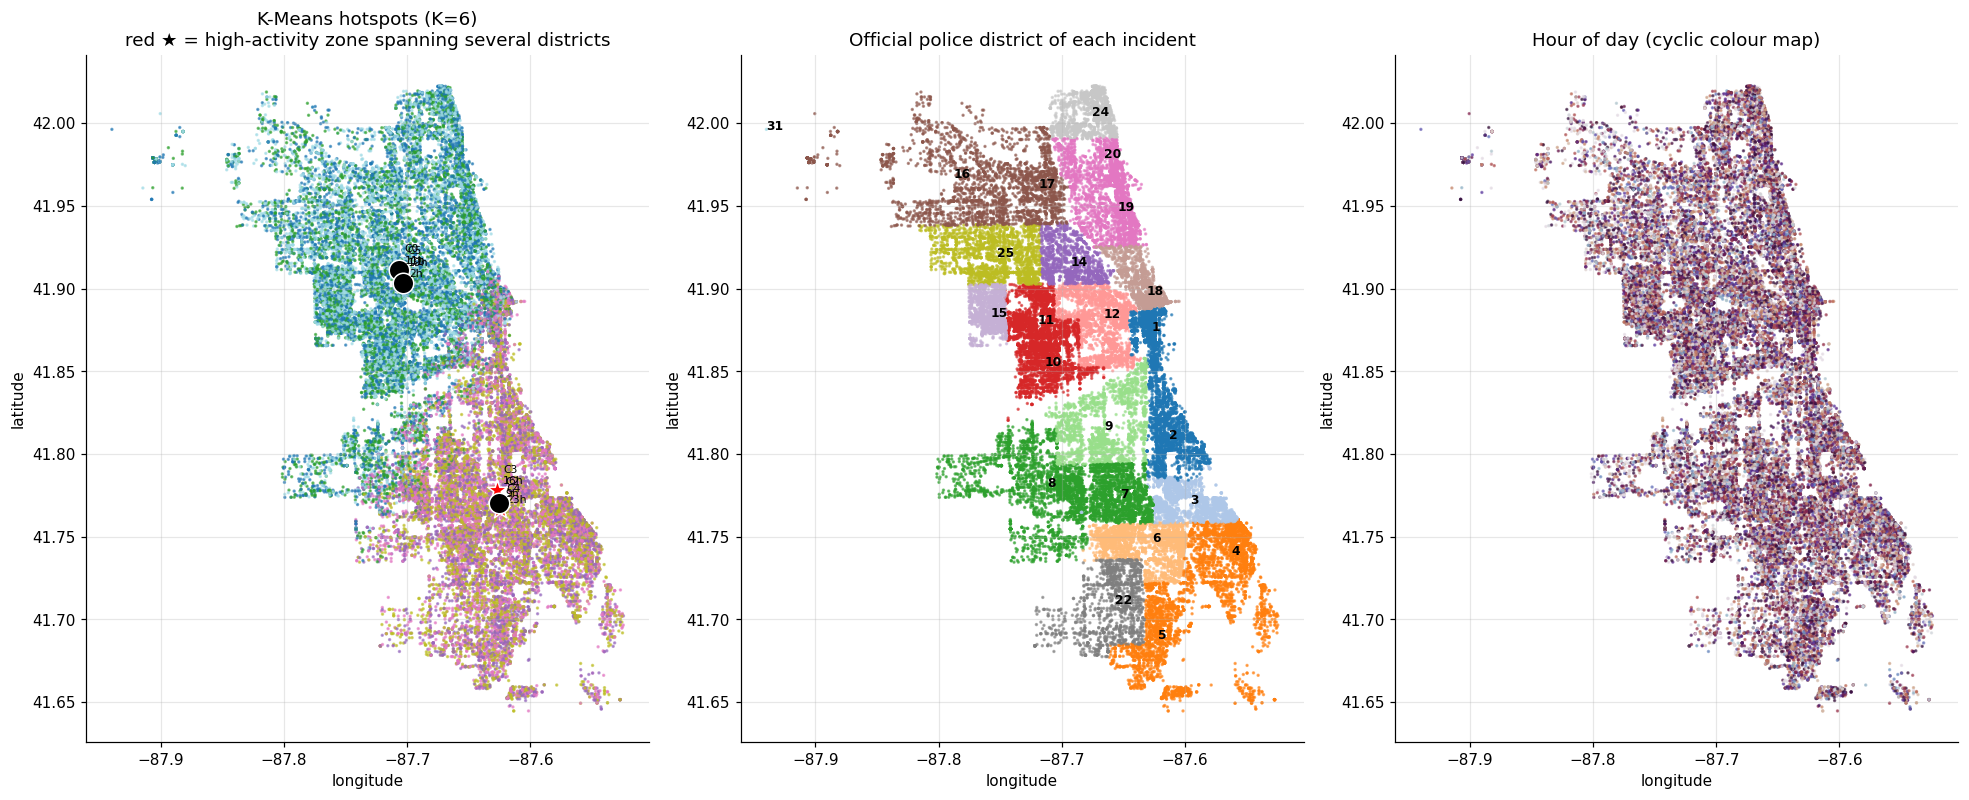

In [ ]:
# ---------- 3.3 Maps: clusters vs official district assignment ----------
samp = pred_opt.select("latitude", "longitude", "cluster", "district", "hour").sample(False, min(1.0, 40000 / max(1, clu.count())), seed=1).toPandas()
fig, ax = plt.subplots(1, 3, figsize=(18, 7))
cmap = plt.get_cmap("tab20", max(K_OPT, 2))
ax[0].scatter(samp.longitude, samp.latitude, c=samp.cluster, cmap=cmap, s=1.5, alpha=0.6)
for _, r in prof_opt.iterrows():
    ax[0].scatter(r.lon, r.lat, s=180, marker="*" if r.HAZ_not_aligned else "o",
                  c="red" if r.HAZ_not_aligned else "black", edgecolor="white", zorder=3)
    ax[0].annotate(f"C{int(r.cluster)}\n{r.peak_hour:.0f}h", (r.lon, r.lat), fontsize=7, xytext=(4, 4), textcoords="offset points")
ax[0].set_title(f"K-Means hotspots (K={K_OPT})\nred ★ = high-activity zone spanning several districts")
ax[1].scatter(samp.longitude, samp.latitude, c=samp.district, cmap="tab20", s=1.5, alpha=0.6)
for d, g in samp.groupby("district"):
    ax[1].annotate(str(d), (g.longitude.median(), g.latitude.median()), fontsize=8, weight="bold")
ax[1].set_title("Official police district of each incident")
ax[2].scatter(samp.longitude, samp.latitude, c=samp.hour, cmap="twilight", s=1.5, alpha=0.6)
ax[2].set_title("Hour of day (cyclic colour map)")
for a in ax:
    a.set_xlabel("longitude"); a.set_ylabel("latitude"); a.set_aspect(1 / np.cos(np.radians(41.85)))
savefig("t3_cluster_maps")

WSSSE coefficient of variation across seeds: 0.59%


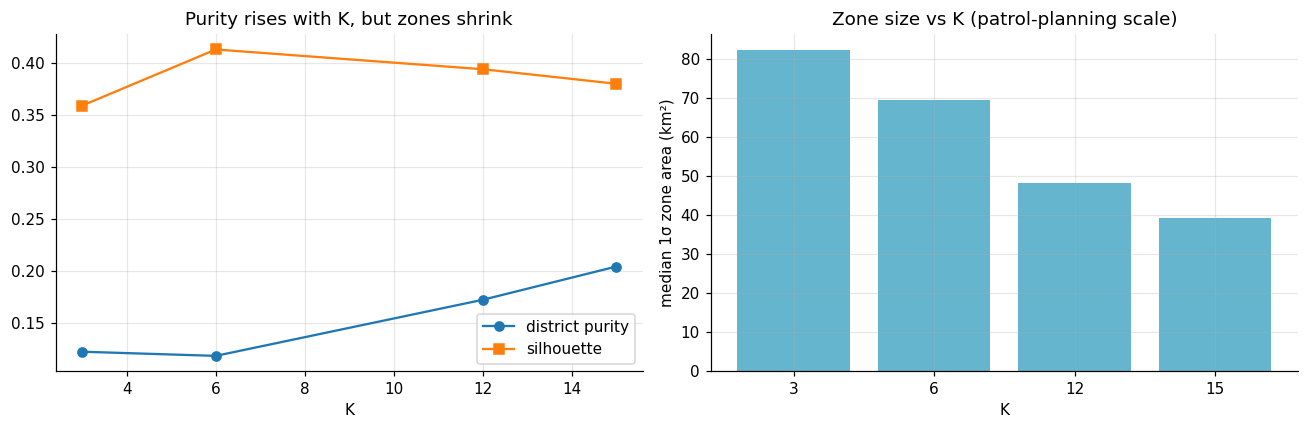

,k,silhouette,weighted_district_purity,median_zone_area_km2,cross_boundary_clusters,HAZ_not_aligned
0,3,0.359,0.122,82.218,3,2
1,6,0.413,0.118,69.341,6,3
2,12,0.394,0.172,48.211,12,6
3,15,0.380,0.204,39.301,14,8


In [ ]:
# ---------- 3.4 How K changes operational interpretability + seed stability ----------
k_list = sorted({max(2, K_OPT // 2), K_OPT, min(max(K_RANGE), K_OPT * 2), max(K_RANGE)})
sens = []
for k in k_list:
    _, p, pr, s = profile(k)
    sens.append((k, s, (pr.district_purity * pr.n).sum() / pr.n.sum(), pr.area_km2.median(),
                 int(pr.cross_boundary.sum()), int(pr.HAZ_not_aligned.sum())))
    p.unpersist()
sens = savetab(pd.DataFrame(sens, columns=["k", "silhouette", "weighted_district_purity", "median_zone_area_km2",
                                           "cross_boundary_clusters", "HAZ_not_aligned"]).round(3), "t3_k_sensitivity")
stab = savetab(pd.DataFrame([(s, KMeans(k=K_OPT, seed=s, maxIter=40).fit(clu).summary.trainingCost) for s in [1, 7, 42, 123, 2024]],
                            columns=["seed", "wssse"]), "t3_seed_stability")
print(f"WSSSE coefficient of variation across seeds: {stab.wssse.std() / stab.wssse.mean() * 100:.2f}%")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(sens.k, sens.weighted_district_purity, marker="o", label="district purity"); ax[0].plot(sens.k, sens.silhouette, marker="s", label="silhouette")
ax[0].set_xlabel("K"); ax[0].legend(); ax[0].set_title("Purity rises with K, but zones shrink")
ax[1].bar(sens.k.astype(str), sens.median_zone_area_km2, color="#64B5CD"); ax[1].set_xlabel("K"); ax[1].set_ylabel("median 1σ zone area (km²)")
ax[1].set_title("Zone size vs K (patrol-planning scale)")
savefig("t3_k_sensitivity")
sens

In [ ]:
pred_opt.unpersist(); clu.unpersist()

DataFrame[id: bigint, latitude: double, longitude: double, hour: int, hour_sin: double, hour_cos: double, district: int, community_area: int, primary_type: string, arrest: boolean, features: vector]

In [ ]:
# Distributed Predictive Modelling

In [ ]:
from pyspark.ml.feature import StringIndexer
from pyspark.ml.classification import RandomForestClassifier, GBTClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.functions import vector_to_array

first_year = MAX_YEAR - MODEL_YEARS + 1
base = (silver.filter((F.col("year") >= first_year) & (F.col("loc_quality") != "missing"))
              .sample(False, MODEL_SAMPLE_FRAC, seed=SEED)
              .join(F.broadcast(weather.select("date", "tmax", "precip_mm", "snow_cm")), "date", "left")
              .join(F.broadcast(socio.select("community_area", "hardship_index", "pct_below_poverty")), "community_area", "left"))
top_locs = [r[0] for r in base.groupBy("location_description").count().orderBy(F.desc("count")).limit(TOP_LOCATIONS).collect()]
base = (base.withColumn("loc_grp", F.when(F.col("location_description").isin(top_locs), F.col("location_description")).otherwise("OTHER"))
            .withColumn("district_s", F.col("district").cast("string"))
            .withColumn("ca_s", F.coalesce(F.col("community_area").cast("string"), F.lit("NA")))
            .withColumn("label", F.col("arrest").cast("double"))
            .withColumn("domestic_d", F.col("domestic").cast("double"))
            .withColumn("weekend_d", F.col("is_weekend").cast("double"))
            .fillna({"tmax": 0.0, "precip_mm": 0.0, "snow_cm": 0.0, "hardship_index": -1.0, "pct_below_poverty": -1.0}))
TEST_YEAR = MAX_YEAR
train_raw = base.filter(F.col("year") < TEST_YEAR)
test_raw = base.filter(F.col("year") == TEST_YEAR).cache()
pos = train_raw.agg(F.avg("label")).first()[0]
# Balanced class weights: w_c = N / (n_classes * n_c)
train_raw = train_raw.withColumn("w", F.when(F.col("label") == 1, 0.5 / pos).otherwise(0.5 / (1 - pos))).cache()
n_tr, n_te = train_raw.count(), test_raw.count()
print(f"Train {n_tr:,} ({first_year}-{TEST_YEAR-1}) | Test {n_te:,} ({TEST_YEAR}) | arrest base rate {pos:.3f}")

cat_in = ["primary_type", "loc_grp", "district_s", "ca_s"]
num_in = ["hour_sin", "hour_cos", "dow", "month", "weekend_d", "domestic_d", "latitude", "longitude",
          "tmax", "precip_mm", "snow_cm", "hardship_index", "pct_below_poverty"]
idx = [StringIndexer(inputCol=c, outputCol=f"{c}_ix", handleInvalid="keep") for c in cat_in]
arrest_feats = [f"{c}_ix" for c in cat_in] + num_in
prep_a = Pipeline(stages=idx + [VectorAssembler(inputCols=arrest_feats, outputCol="features")]).fit(train_raw)
tr_a, te_a = prep_a.transform(train_raw).cache(), prep_a.transform(test_raw).cache()
MAX_BINS = max(100, len(top_locs) + 5)

Train 276,106 (2019-2022) | Test 22,176 (2023) | arrest base rate 0.157


In [ ]:
# ---------- 4A.1 Train three arrest models ----------
models_a = {
    "RF (unweighted)":  RandomForestClassifier(numTrees=RF_TREES, maxDepth=12, maxBins=MAX_BINS, subsamplingRate=0.8,
                                               featureSubsetStrategy="sqrt", seed=SEED),
    "RF (class-weighted)": RandomForestClassifier(numTrees=RF_TREES, maxDepth=12, maxBins=MAX_BINS, subsamplingRate=0.8,
                                                  featureSubsetStrategy="sqrt", seed=SEED, weightCol="w"),
    "GBT (class-weighted)": GBTClassifier(maxIter=GBT_ITERS, maxDepth=6, maxBins=MAX_BINS, stepSize=0.1, seed=SEED, weightCol="w"),
}
fitted_a, preds_a, times_a = {}, {}, {}
for name, est in models_a.items():
    t0 = time.time(); fitted_a[name] = est.fit(tr_a); times_a[name] = time.time() - t0
    preds_a[name] = (fitted_a[name].transform(te_a)
                     .withColumn("p1", vector_to_array("probability")[1])
                     .select("label", "prediction", "p1", "primary_type").cache())
    print(f"{name}: trained in {times_a[name]:.1f}s")

RF (unweighted): trained in 363.7s
RF (class-weighted): trained in 352.1s
GBT (class-weighted): trained in 186.3s


In [ ]:
# ---------- 4A.2 Evaluation: confusion matrix, precision, recall, F1, ROC/PR (computed in Spark) ----------
def binary_eval(pred, thr=0.5):
    p = pred.withColumn("yhat", (F.col("p1") >= thr).cast("double"))
    cm = {(int(r.label), int(r.yhat)): r["count"] for r in p.groupBy("label", "yhat").count().collect()}
    tp, fp, fn, tn = cm.get((1, 1), 0), cm.get((0, 1), 0), cm.get((1, 0), 0), cm.get((0, 0), 0)
    prec = tp / (tp + fp) if tp + fp else 0.0; rec = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * prec * rec / (prec + rec) if prec + rec else 0.0
    return dict(threshold=thr, TP=tp, FP=fp, FN=fn, TN=tn, accuracy=(tp + tn) / max(1, tp + fp + fn + tn),
                precision=prec, recall=rec, f1=f1, specificity=tn / max(1, tn + fp))

def curve_points(pred, bins=200):
    # distributed histogram of scores per class, then cumulative sums on the driver (200 rows)
    h = (pred.withColumn("b", F.least(F.floor(F.col("p1") * bins), F.lit(bins - 1)))
             .groupBy("b").agg(F.sum("label").alias("pos"), F.sum(1 - F.col("label")).alias("neg")).toPandas()
             .set_index("b").reindex(range(bins), fill_value=0).sort_index(ascending=False))
    tp, fp = h.pos.cumsum(), h.neg.cumsum()
    P, N = h.pos.sum(), h.neg.sum()
    thr = np.array(h.index) / bins
    return pd.DataFrame({"thr": thr, "tpr": tp / P, "fpr": fp / N, "precision": np.where(tp + fp > 0, tp / np.maximum(tp + fp, 1), np.nan), "recall": tp / P}).dropna()

roc_eval = BinaryClassificationEvaluator(rawPredictionCol="p1", labelCol="label", metricName="areaUnderROC")
pr_eval = BinaryClassificationEvaluator(rawPredictionCol="p1", labelCol="label", metricName="areaUnderPR")
rows, curves = [], {}
for name, p in preds_a.items():
    curves[name] = c = curve_points(p)
    f1s = 2 * c.precision * c.recall / (c.precision + c.recall).replace(0, np.nan)
    best_thr = float(c.thr.iloc[int(np.nanargmax(f1s.values))])
    auc_roc, auc_pr = roc_eval.evaluate(p), pr_eval.evaluate(p)
    for thr in (0.5, best_thr):
        m = binary_eval(p, thr)
        rows.append(dict(model=name, auc_roc=auc_roc, auc_pr=auc_pr, train_s=times_a[name], **m))
arrest_metrics = savetab(pd.DataFrame(rows).round(4), "t4_arrest_metrics")
arrest_metrics[["model", "threshold", "auc_roc", "auc_pr", "accuracy", "precision", "recall", "f1", "TP", "FP", "FN", "TN"]]

,model,threshold,auc_roc,auc_pr,accuracy,precision,recall,f1,TP,FP,FN,TN
0,RF (unweighted),0.500,0.8725,0.6307,0.9141,0.8341,0.3563,0.4993,950,189,1716,19321
1,RF (unweighted),0.280,0.8725,0.6307,0.9123,0.6859,0.4996,0.5781,1332,610,1334,18900
2,RF (class-weighted),0.500,0.8715,0.6171,0.8313,0.3874,0.6928,0.4969,1847,2921,819,16589
3,RF (class-weighted),0.625,0.8715,0.6171,0.9099,0.6720,0.4887,0.5659,1303,636,1363,18874
4,GBT (class-weighted),0.500,0.8805,0.6470,0.7961,0.3461,0.7824,0.4799,2086,3942,580,15568
5,GBT (class-weighted),0.760,0.8805,0.6470,0.9115,0.6702,0.5199,0.5856,1386,682,1280,18828


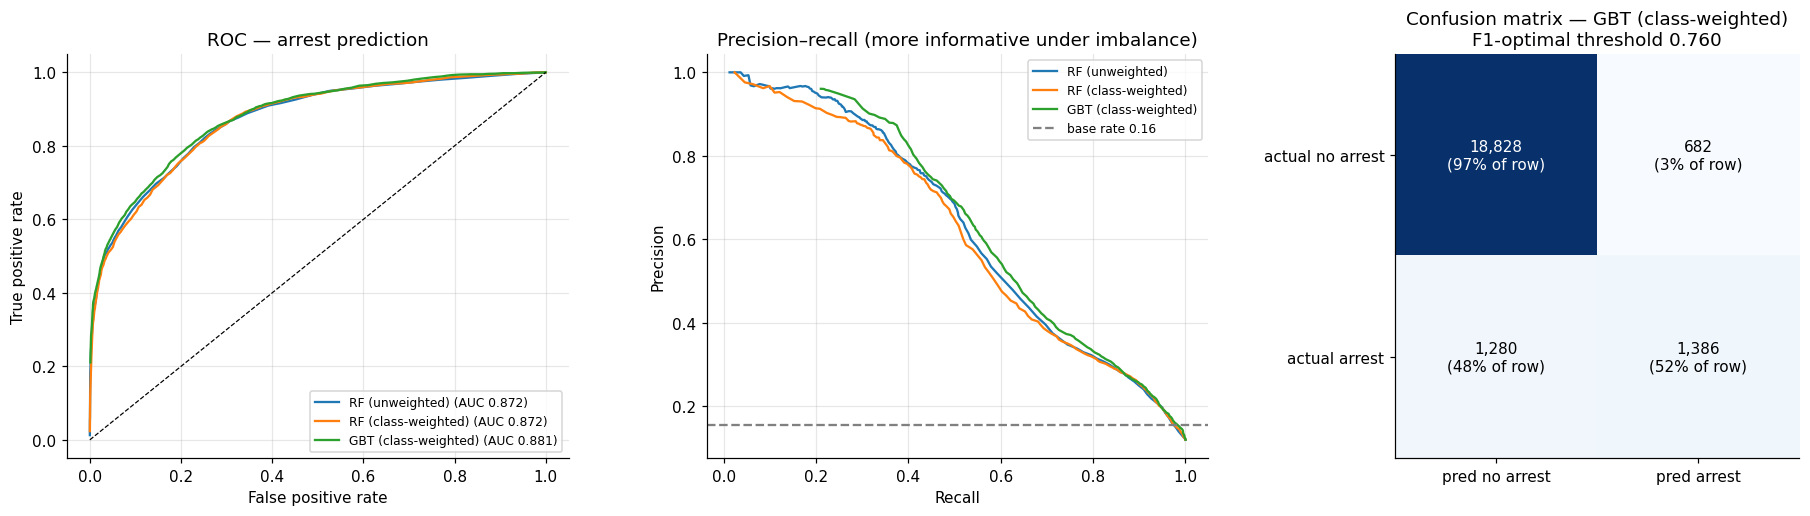

In [ ]:
best_name = arrest_metrics.sort_values("auc_pr", ascending=False).model.iloc[0]
best_row = arrest_metrics[(arrest_metrics.model == best_name)].sort_values("f1").iloc[-1]
fig, ax = plt.subplots(1, 3, figsize=(17, 4.8))
for name, c in curves.items():
    ax[0].plot(c.fpr, c.tpr, label=f"{name} (AUC {roc_eval.evaluate(preds_a[name]):.3f})")
    ax[1].plot(c.recall, c.precision, label=name)
ax[0].plot([0, 1], [0, 1], "k--", lw=0.8); ax[0].set_xlabel("False positive rate"); ax[0].set_ylabel("True positive rate")
ax[0].set_title("ROC — arrest prediction"); ax[0].legend(fontsize=8)
ax[1].axhline(pos, ls="--", c="grey", label=f"base rate {pos:.2f}"); ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision")
ax[1].set_title("Precision–recall (more informative under imbalance)"); ax[1].legend(fontsize=8)
cm = np.array([[best_row.TN, best_row.FP], [best_row.FN, best_row.TP]])
ax[2].imshow(cm, cmap="Blues"); ax[2].grid(False)
for (i, j), v in np.ndenumerate(cm):
    ax[2].text(j, i, f"{int(v):,}\n({v / cm[i].sum():.0%} of row)", ha="center", va="center",
               color="white" if v > cm.max() / 2 else "black")
ax[2].set_xticks([0, 1]); ax[2].set_xticklabels(["pred no arrest", "pred arrest"])
ax[2].set_yticks([0, 1]); ax[2].set_yticklabels(["actual no arrest", "actual arrest"])
ax[2].set_title(f"Confusion matrix — {best_name}\nF1-optimal threshold {best_row.threshold:.3f}")
savefig("t4_arrest_roc_pr_cm")

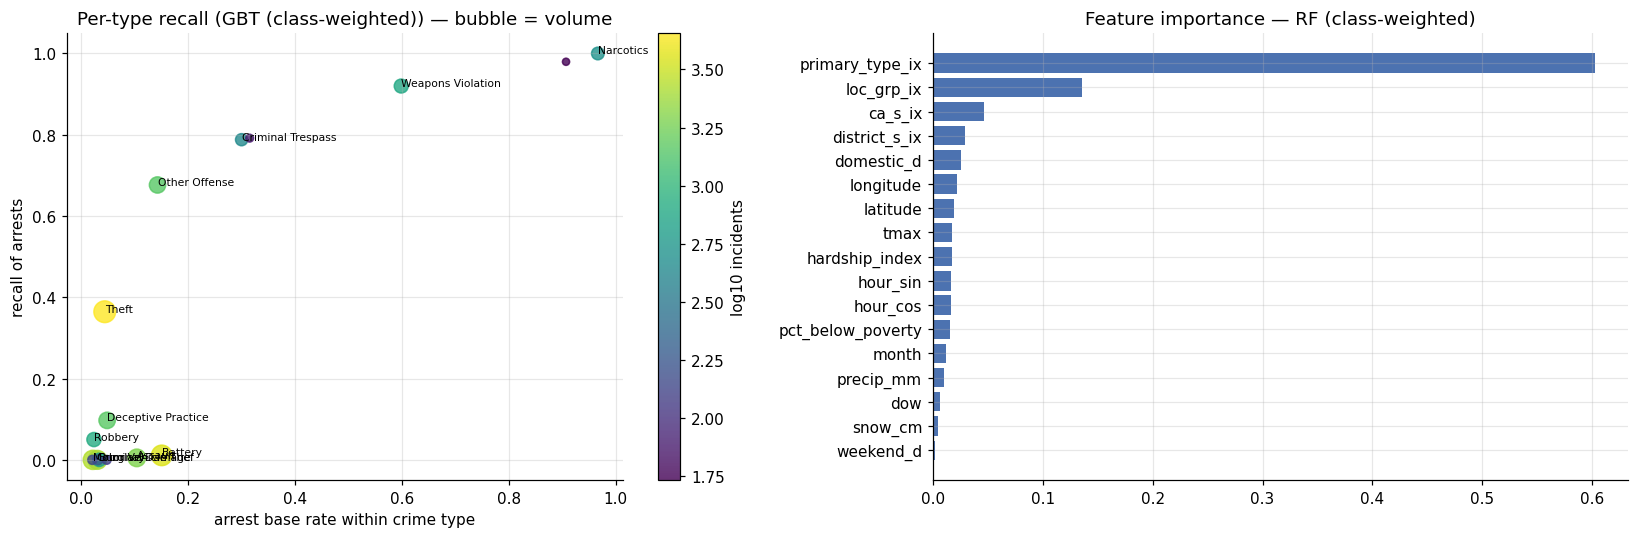

,primary_type,n,arrest_base_rate,tp,fp,positives,recall,precision,share_of_test
0,THEFT,4528,0.045,74,128,203.0,0.365,0.366,0.204
1,BATTERY,3586,0.151,6,6,543.0,0.011,0.500,0.162
2,MOTOR VEHICLE THEFT,2712,0.022,0,1,61.0,0.000,0.000,0.122
3,CRIMINAL DAMAGE,2545,0.031,0,1,79.0,0.000,0.000,0.115
4,ASSAULT,1938,0.105,1,3,203.0,0.005,0.250,0.087
5,DECEPTIVE PRACTICE,1462,0.049,7,0,72.0,0.097,1.000,0.066
6,OTHER OFFENSE,1422,0.143,138,142,204.0,0.676,0.493,0.064
7,ROBBERY,813,0.025,1,0,20.0,0.050,1.000,0.037
8,WEAPONS VIOLATION,771,0.599,425,204,462.0,0.920,0.676,0.035
9,BURGLARY,640,0.034,0,0,22.0,0.000,NaN,0.029


In [ ]:
# ---------- 4A.3 How crime-type skew drives precision/recall ----------
bp = preds_a[best_name].withColumn("yhat", (F.col("p1") >= float(best_row.threshold)).cast("int"))
per_type = (bp.groupBy("primary_type").agg(
                F.count("*").alias("n"), F.avg("label").alias("arrest_base_rate"),
                F.sum(F.when((F.col("label") == 1) & (F.col("yhat") == 1), 1).otherwise(0)).alias("tp"),
                F.sum(F.when((F.col("label") == 0) & (F.col("yhat") == 1), 1).otherwise(0)).alias("fp"),
                F.sum("label").alias("positives"))
            .withColumn("recall", F.col("tp") / F.col("positives"))
            .withColumn("precision", F.col("tp") / (F.col("tp") + F.col("fp")))
            .withColumn("share_of_test", F.col("n") / F.lit(n_te))
            .filter("n >= 50").orderBy(F.desc("n")).toPandas())
savetab(per_type.round(4), "t4_arrest_by_type")

rf_best = fitted_a["RF (class-weighted)"]
imp = pd.Series(rf_best.featureImportances.toArray(), index=arrest_feats).sort_values()
savetab(imp.reset_index().rename(columns={"index": "feature", 0: "importance"}), "t4_arrest_feature_importance")

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sc_ = ax[0].scatter(per_type.arrest_base_rate, per_type.recall, s=np.sqrt(per_type.n) * 3, c=np.log10(per_type.n), cmap="viridis", alpha=0.8)
for _, r in per_type.head(12).iterrows():
    ax[0].annotate(r.primary_type.title()[:18], (r.arrest_base_rate, r.recall), fontsize=7)
ax[0].set_xlabel("arrest base rate within crime type"); ax[0].set_ylabel("recall of arrests")
ax[0].set_title(f"Per-type recall ({best_name}) — bubble = volume"); plt.colorbar(sc_, ax=ax[0], label="log10 incidents")
ax[1].barh(imp.index, imp.values, color="#4C72B0"); ax[1].set_title("Feature importance — RF (class-weighted)")
savefig("t4_arrest_skew_importance")
per_type.head(15).round(3)

In [ ]:
# ---------- 4B. Multiclass Primary Type model: the clearest view of data skew ----------
top_types = [r[0] for r in train_raw.groupBy("primary_type").count().orderBy(F.desc("count")).limit(TOP_TYPES).collect()]
def with_type_label(df):
    return df.withColumn("ptype", F.when(F.col("primary_type").isin(top_types), F.col("primary_type")).otherwise("OTHER"))
tr_m, te_m = with_type_label(train_raw), with_type_label(test_raw)
cls_counts = tr_m.groupBy("ptype").count().toPandas().set_index("ptype")["count"]
n_cls = len(cls_counts)
wmap = {k: float(min(10.0, cls_counts.sum() / (n_cls * v))) for k, v in cls_counts.items()}    # balanced, capped at 10x
wexpr = F.create_map(*[F.lit(x) for kv in wmap.items() for x in kv])
tr_m = tr_m.withColumn("wc", wexpr[F.col("ptype")])

type_feats = ["loc_grp_ix", "district_s_ix", "ca_s_ix", "hour_sin", "hour_cos", "dow", "month", "weekend_d",
              "domestic_d", "latitude", "longitude", "tmax", "precip_mm", "snow_cm", "hardship_index", "pct_below_poverty"]
prep_m = Pipeline(stages=[StringIndexer(inputCol="ptype", outputCol="label_t", stringOrderType="frequencyDesc")] +
                  [StringIndexer(inputCol=c, outputCol=f"{c}_ix", handleInvalid="keep") for c in ["loc_grp", "district_s", "ca_s"]] +
                  [VectorAssembler(inputCols=type_feats, outputCol="features")]).fit(tr_m)
labels_t = prep_m.stages[0].labels
trm, tem = prep_m.transform(tr_m).cache(), prep_m.transform(te_m).filter(F.col("ptype").isin(labels_t)).cache()

def per_class(pred):
    cmx = (pred.groupBy("label_t", "prediction").count().toPandas().astype({"label_t": int, "prediction": int})
           .pivot(index="label_t", columns="prediction", values="count").reindex(index=range(n_cls), columns=range(n_cls)).fillna(0))
    tp = np.diag(cmx.values); prec = tp / np.maximum(cmx.sum(0).values, 1); rec = tp / np.maximum(cmx.sum(1).values, 1)
    f1 = np.where(prec + rec > 0, 2 * prec * rec / np.maximum(prec + rec, 1e-12), 0)
    return cmx, pd.DataFrame({"class": labels_t, "support": cmx.sum(1).values.astype(int), "precision": prec, "recall": rec, "f1": f1})

out_m, cms = {}, {}
for name, wcol in [("RF multiclass (unweighted)", None), ("RF multiclass (class-weighted)", "wc")]:
    kw = dict(weightCol=wcol) if wcol else {}
    t0 = time.time()
    m = RandomForestClassifier(labelCol="label_t", numTrees=RF_TREES, maxDepth=12, maxBins=MAX_BINS,
                               featureSubsetStrategy="sqrt", subsamplingRate=0.8, seed=SEED, **kw).fit(trm)
    p = m.transform(tem).cache()
    cms[name], pc = per_class(p)
    ovr = []
    probs = p.withColumn("pa", vector_to_array("probability"))
    for i in range(n_cls):
        ovr.append(BinaryClassificationEvaluator(rawPredictionCol="s", labelCol="y").evaluate(
            probs.select(F.col("pa")[i].alias("s"), (F.col("label_t") == i).cast("double").alias("y"))))
    pc["ovr_auc"] = ovr
    out_m[name] = pc
    acc = pc.support.dot(pc.recall) / pc.support.sum()
    print(f"{name}: {time.time()-t0:.0f}s | accuracy {acc:.3f} | macro-F1 {pc.f1.mean():.3f} | "
          f"weighted-F1 {np.average(pc.f1, weights=pc.support):.3f} | macro OvR AUC {np.mean(ovr):.3f}")
    p.unpersist()

cmp = out_m["RF multiclass (unweighted)"].merge(out_m["RF multiclass (class-weighted)"], on=["class", "support"], suffixes=("_unw", "_w"))
cmp["share"] = cmp.support / cmp.support.sum()
savetab(cmp.round(4), "t4_type_per_class")
cmp[["class", "share", "precision_unw", "recall_unw", "f1_unw", "precision_w", "recall_w", "f1_w", "ovr_auc_w"]].round(3)

RF multiclass (unweighted): 753s | accuracy 0.320 | macro-F1 0.173 | weighted-F1 0.240 | macro OvR AUC 0.759
RF multiclass (class-weighted): 816s | accuracy 0.299 | macro-F1 0.239 | weighted-F1 0.276 | macro OvR AUC 0.760


,class,share,precision_unw,recall_unw,f1_unw,precision_w,recall_w,f1_w,ovr_auc_w
0,THEFT,0.204,0.277,0.813,0.413,0.465,0.259,0.333,0.709
1,BATTERY,0.162,0.487,0.600,0.538,0.526,0.498,0.512,0.824
2,CRIMINAL DAMAGE,0.115,0.201,0.108,0.141,0.234,0.010,0.020,0.652
3,OTHER,0.079,0.257,0.175,0.208,0.271,0.152,0.195,0.646
4,ASSAULT,0.087,0.143,0.001,0.001,0.221,0.046,0.077,0.659
5,DECEPTIVE PRACTICE,0.066,0.383,0.362,0.372,0.273,0.589,0.373,0.860
6,OTHER OFFENSE,0.064,0.500,0.001,0.001,0.200,0.062,0.095,0.704
7,MOTOR VEHICLE THEFT,0.122,0.365,0.024,0.045,0.342,0.505,0.408,0.840
8,BURGLARY,0.029,0.400,0.019,0.036,0.130,0.594,0.213,0.873
9,WEAPONS VIOLATION,0.035,0.246,0.096,0.138,0.125,0.488,0.200,0.825


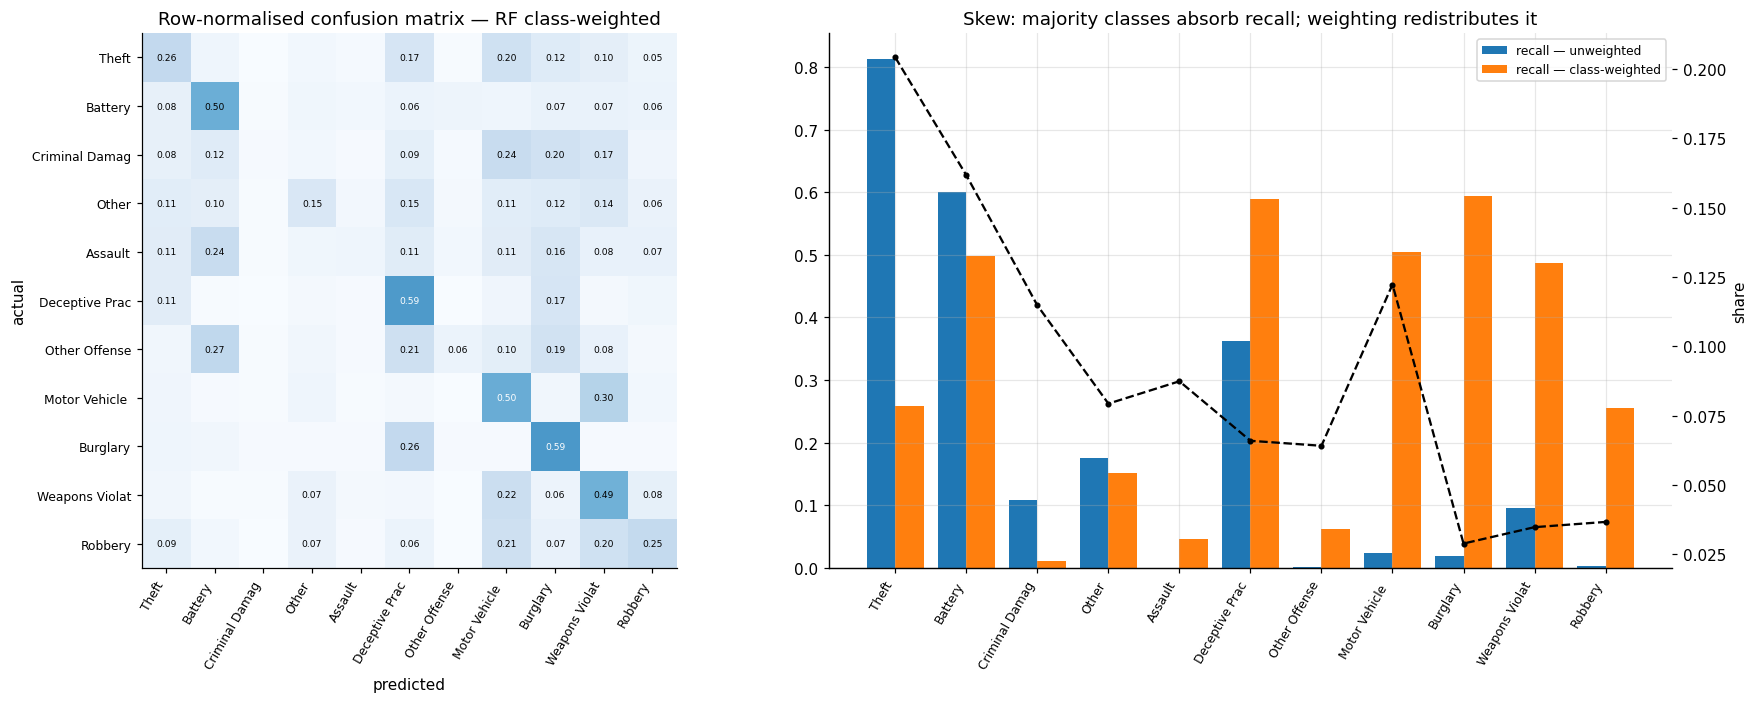

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(17, 6.5))
cmn = cms["RF multiclass (class-weighted)"].values
cmn = cmn / np.maximum(cmn.sum(1, keepdims=True), 1)
im = ax[0].imshow(cmn, cmap="Blues", vmin=0, vmax=1); ax[0].grid(False)
short = [l.title()[:14] for l in labels_t]
ax[0].set_xticks(range(n_cls)); ax[0].set_xticklabels(short, rotation=60, ha="right", fontsize=8)
ax[0].set_yticks(range(n_cls)); ax[0].set_yticklabels(short, fontsize=8)
for (i, j), v in np.ndenumerate(cmn):
    if v >= 0.05: ax[0].text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=6, color="white" if v > 0.5 else "black")
ax[0].set_title("Row-normalised confusion matrix — RF class-weighted"); ax[0].set_xlabel("predicted"); ax[0].set_ylabel("actual")
x = np.arange(n_cls)
ax[1].bar(x - 0.2, cmp.recall_unw, 0.4, label="recall — unweighted"); ax[1].bar(x + 0.2, cmp.recall_w, 0.4, label="recall — class-weighted")
ax2 = ax[1].twinx(); ax2.plot(x, cmp.share, "k.--", label="class share of test set"); ax2.set_ylabel("share"); ax2.grid(False)
ax[1].set_xticks(x); ax[1].set_xticklabels([c.title()[:14] for c in cmp["class"]], rotation=60, ha="right", fontsize=8)
ax[1].set_title("Skew: majority classes absorb recall; weighting redistributes it"); ax[1].legend(loc="upper right", fontsize=8)
savefig("t4_type_skew")

In [ ]:
# ---------- Package figures + tables for the report ----------
for d in (tr_a, te_a, trm, tem, train_raw, test_raw):
    d.unpersist()
import zipfile
zip_path = f"{BASE}/report_assets.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for folder in (FIG, TAB):
        for fpath in glob.glob(f"{folder}/*"):
            z.write(fpath, arcname=os.path.join(os.path.basename(folder), os.path.basename(fpath)))
print("Figures:", len(glob.glob(f"{FIG}/*.png")), "| tables:", len(glob.glob(f"{TAB}/*.csv")), "->", zip_path)
if IN_COLAB:
    from google.colab import files
    files.download(zip_path)

Figures: 12 | tables: 22 -> /content/chicago_crime/report_assets.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>